### 1. Introducción a la Modulación OFDM

La **Modulación por División de Frecuencia Ortogonal (OFDM)** es una técnica de modulación digital multiportadora que divide un canal de banda ancha en un gran número de subcanales de banda estrecha, conocidos como **subportadoras**. La clave de OFDM reside en la **ortogonalidad** de estas subportadoras, lo que permite que sus espectros se solapen sin causar interferencia entre sí, logrando una alta eficiencia espectral.

Las principales ventajas que han convertido a OFDM en la base de estándares modernos como Wi-Fi (802.11a/g/n/ac/ax), LTE, 5G y DVB son:

*   **Robustez contra la Interferencia Intersimbólica (ISI):** Al transmitir datos en paralelo sobre muchas subportadoras lentas, la duración de cada símbolo se incrementa significativamente. Esto hace que el retardo del canal (multipath delay spread) sea una fracción pequeña de la duración del símbolo, mitigando la ISI.
*   **Eliminación de la ISI con el Prefijo Cíclico (CP):** Se introduce un intervalo de guarda (Guard Interval) antes de cada símbolo, usualmente una copia del final del propio símbolo (Prefijo Cíclico). Esto cumple dos funciones:
    1.  Absorbe la ISI del símbolo anterior, dejando la parte útil del símbolo actual intacta.
    2.  Convierte la convolución lineal del canal en una convolución circular, lo que simplifica enormemente la ecualización en el receptor.
*   **Eficiencia Computacional:** En lugar de utilizar un banco de moduladores y demoduladores analógicos (uno por subportadora), OFDM se implementa eficientemente en el dominio digital mediante la **Transformada Inversa Rápida de Fourier (IFFT)** en el transmisor y la **Transformada Rápida de Fourier (FFT)** en el receptor.
*   **Ecualización Sencilla:** Gracias al prefijo cíclico, el efecto de un canal selectivo en frecuencia se reduce a una simple multiplicación por un escalar complejo en cada subportadora. Esto permite una ecualización de un solo toque (one-tap equalizer) por subportadora, mucho más simple que los ecualizadores complejos necesarios en sistemas de portadora única.

### 2. Flujo de Transmisión y Recepción (Visión Ideal)

El proceso completo, desde los bits de entrada hasta los bits recuperados, sigue una serie de pasos bien definidos.

#### **Proceso del Transmisor OFDM:**

1.  **Generación de Bits:** Se crea una secuencia de bits binarios aleatorios como fuente de datos.
2.  **Mapeo de Símbolos:** Los bits se agrupan y se mapean a símbolos complejos (`a_k`) de una constelación digital (ej. QPSK, 16-QAM).
3.  **Construcción del Vector de Frecuencia:** Los `K` símbolos complejos se agrupan y se colocan en un vector de `N` puntos (`X_m`), rellenando las `N-K` posiciones restantes con ceros. Cada vector formará la entrada para un símbolo OFDM.
4.  **Modulación IFFT:** Se aplica la IFFT a cada vector `X_m` de `N` puntos. Esto transforma los datos del dominio de la frecuencia al dominio del tiempo, generando `N` muestras de tiempo complejas (`x_n`).
5.  **Inserción del Prefijo Cíclico (CP):** Se copian las últimas `L` muestras de la salida de la IFFT y se anteponen al bloque. El símbolo OFDM ahora tiene `N + L` muestras.
6.  **Conversión Paralelo a Serie (P/S):** Los símbolos OFDM se concatenan para formar la trama de datos a transmitir.

![Transmisor](../img/transmisor.png)

#### **Proceso del Receptor OFDM:**

1.  **Sincronización y Conversión S/P:** El receptor se sincroniza con la trama recibida y la divide en bloques de `N + L` muestras.
2.  **Eliminación del Prefijo Cíclico:** Se descartan las primeras `L` muestras de cada bloque, eliminando el CP.
3.  **Demodulación FFT:** Se aplica la FFT a las `N` muestras restantes para transformar la señal de vuelta al dominio de la frecuencia. La salida son los `N` puntos `Y_m`.
4.  **Ecualización y Extracción de Datos:** Se extraen los `K` símbolos de datos de `Y_m` y se corrige la atenuación y el desfase introducidos por el canal.
5.  **Demapeo de Símbolos:** Cada símbolo complejo recuperado se decide al punto más cercano de la constelación original.
6.  **Conversión Paralelo a Serie y Recuperación de Bits:** Los símbolos decididos se convierten de nuevo a bits, y estos se concatenan para formar la secuencia de datos recuperada.
7.  **Cálculo de BER:** Se comparan los bits transmitidos con los recuperados para medir el rendimiento.

Con estos fundamentos establecidos, procederemos a implementar cada bloque en Python.

![Receptor](../img/receptor.png)

### 0. Parámetros globales

Sea  
\[
\begin{aligned}
K      &= \text{nº de subportadoras de datos} \\
N      &= \text{tamaño de la IFFT/DFT} \\
M      &= \text{orden de modulación (QPSK → 4)} \\
\mu    &= \log_2 M \quad (\text{bits por símbolo}) \\
L      &= \text{longitud del prefijo cíclico (en muestras)} \\
f_\Delta &= \text{espaciado entre subportadoras} \\
T_{obs} &= \frac{1}{f_\Delta} \quad (\text{duración útil del símbolo}) \\
f_{samp} &= N \cdot f_\Delta \quad (\text{frecuencia de muestreo}) \\
T_{cp}   &= \frac{L}{f_{samp}} \quad (\text{duración del prefijo cíclico}) \\
T_s      &= T_{obs} + T_{cp} \quad (\text{duración total del símbolo}) \\
\end{aligned}
\]

In [1]:
# --- Importaciones de bibliotecas estándar ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Importaciones de nuestro paquete local ---
# Añadimos la ruta al directorio padre para que Python encuentre la carpeta 'src'
import sys
sys.path.append('../')

from src.ofdm_tf import transmisor as transmisor
from src.ofdm_tf import receptor as receptor
from src.ofdm_tf import params as p
from src.ofdm_tf import utils
from src.ofdm_tf import mapping as mp
from src.ofdm_tf import channel as ch 
from src.ofdm_tf import demapping as dmp
from scipy.special import erfc

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
print("--- Entorno listo ---")

Número de subportadoras de datos (K): 12
Tamaño de la IFFT (N): 16
Longitud del Prefijo Cíclico (L): 1
Duración útil (T_obs): 1.00 s
Duración CP (T_cp): 0.06 s
Duración total del símbolo (T_s): 1.06 s
Frecuencia de muestreo (fsamp): 16.00 Hz
Espaciado de subportadoras (f_delta): 1.00 Hz

--- Parámetros configurados correctamente ---
Módulo 'mapping.py' cargado y listo.
Módulo 'demapping.py' cargado y listo.
Módulo 'channel.py' cargado.
  - h (taps): [0.+0.j]
  - soporte efectivo: n0=0, n1=-1  => L_h_eff=0 taps
  - CP requerido: L_req=0 (taps). CP configurado: L=1
--- Entorno listo ---


In [2]:
# --- Bloque 0.1: Panel de Control de la Simulación ---

# Modifica estos parámetros para cambiar el comportamiento de todo el notebook.

# MODO_CANAL: Define el tipo de canal a utilizar.
# Opciones: "ideal", "awgn"
MODO_CANAL = "awgn"

# EBN0_DB: Define el nivel de Eb/N0 en dB.
# Se usa SOLO si MODO_CANAL es "awgn".
# Para una sola ejecución
# Para la curva BER, este valor se ignorará y se usará el del bucle.
EBN0_DB_SINGLE_RUN = 8 

print("--- Configuración de la Simulación ---")
print(f"Modo del Canal: {MODO_CANAL}")
if MODO_CANAL == "awgn":
    print(f"Eb/N0 para ejecución única: {EBN0_DB_SINGLE_RUN} dB")
print("-------------------------------------")

--- Configuración de la Simulación ---
Modo del Canal: awgn
Eb/N0 para ejecución única: 8 dB
-------------------------------------


### Bloque 1: Generador de la Secuencia de Bits de Origen

Toda comunicación digital comienza con una fuente de información. En nuestra simulación, esta fuente será una secuencia de **bits binarios** aleatorios (una sucesión de 0s y 1s), que representará los datos que queremos transmitir, como podrían ser un archivo de texto, una imagen o un fragmento de audio.

#### ¿Qué es una Subportadora y por qué es Clave en OFDM?

OFDM divide el ancho de banda total en múltiples subcanales ortogonales de banda estrecha. Cada uno de estos subcanales es modulado por una **subportadora**: una onda sinusoidal de una frecuencia específica que puede transportar una pequeña cantidad de información de forma independiente.

En nuestro sistema, hemos definido `K` subportadoras de datos. Esto significa que en cada instante de tiempo (definido por la duración de un "símbolo OFDM"), transmitiremos `K` piezas de información simultáneamente, una por cada carril o subportadora.

#### ¿Cuántos Bits Necesitamos Generar?

Para llevar a cabo una simulación robusta, no basta con transmitir un solo símbolo OFDM. Necesitamos enviar una gran cantidad de ellos (`N_sym`) para poder medir el rendimiento del sistema de forma estadísticamente fiable (por ejemplo, al calcular la Tasa de Error de Bit o BER).

La cantidad total de bits que necesitamos generar se calcula multiplicando tres factores clave:

1.  **El número de símbolos OFDM que enviaremos (`N_sym`):** Es la duración de nuestra "transmisión" simulada.
2.  **El número de subportadoras de datos por cada símbolo OFDM (`K`):** Es la cantidad de "paquetes" de datos que enviamos en paralelo en cada instante.
3.  **El número de bits que caben en cada subportadora (`mu`):** Depende de la complejidad de la modulación que usemos. Para QPSK, cada subportadora transporta 2 bits de información.

Por lo tanto, la fórmula para la longitud total de la secuencia de bits es:

$$ L_{bits} = (\text{Número de Símbolos OFDM}) \times (\text{Subportadoras de Datos por Símbolo}) \times (\text{Bits por Subportadora}) $$
$$ L_{bits} = N_{sym} \times K \times \mu $$

Por ejemplo, si simulamos 10,000 símbolos OFDM, con 64 subportadoras de datos cada uno, y cada subportadora lleva 2 bits (QPSK), necesitaremos generar un total de $10,000 \times 64 \times 2 = 1,280,000$ bits.

#### Garantizando la Reproducibilidad

Para que nuestra simulación sea científica, debe ser **reproducible**. Esto significa que si volvemos a ejecutar el código, debemos obtener exactamente los mismos resultados. Para lograrlo, utilizamos un Generador de Números Aleatorios (`RNG`) con una **semilla (seed)** fija. Esto asegura que la secuencia "aleatoria" de bits que generemos sea siempre la misma en cada ejecución, lo cual es fundamental para depurar errores y validar resultados.

### Aleatoriedad uniforme y variación muestral

En la simulación OFDM, la secuencia de bits transmitida se genera de forma pseudoaleatoria con **equiprobabilidad**:

$$
\Pr\{0\}=\Pr\{1\}=0.5
$$

Dado que trabajamos con una **muestra finita** de longitud $L_{\text{bits}}$, la proporción observada de unos (o la media muestral de los bits, considerados Bernoulli {0,1}) no será exactamente 0.5.
Por la **Ley de los Grandes Números**, esa media converge a 0.5 cuando $L_{\text{bits}} \to \infty$.

Para tamaño finito, la **incertidumbre muestral** se cuantifica por el **error estándar** (ES) de la media:

$$
\text{ES} = \sqrt{\frac{p(1-p)}{L_{\text{bits}}}}, \qquad p=0.5 \implies \text{ES} = \frac{1}{2\sqrt{L_{\text{bits}}}}.
$$

**Ejemplo numérico.**
Si se generan $L_{\text{bits}} = 1,280,000$ bits:

$$
\text{ES} = \frac{1}{2\sqrt{1,280,000}} \approx 4.42 \times 10^{-4}.
$$

Aquí interviene el **Teorema del Límite Central (TLC)**. Este teorema fundamental establece que, para un tamaño de muestra suficientemente grande (como es el caso con $L_{\text{bits}} = 1,280,000$), la distribución de la media muestral ($\hat{p}$) se aproxima a una distribución Normal (Gaussiana).

Esta aproximación a la normalidad es lo que nos permite utilizar el cuantil $z=1.96$ (correspondiente al 95% de una distribución normal estándar) para construir un **intervalo de confianza del 95 %**:

$$
\hat{p} \in 0.5 \pm 1.96 \cdot \text{ES} \quad \implies \quad \hat{p} \in [\,0.49913,\;0.50087\,].
$$

Esta desviación esperable es muy pequeña y no compromete la validez de la simulación; simplemente refleja la variabilidad inherente a un muestreo finito.


##### **Fundamento teórico de la equiprobabilidad**

La probabilidad de error promedio se define de manera general como:

$$
P_e = \sum_{i=1}^M P(s_i) \cdot P(e|s_i)
$$

donde $ P(s_i) $ es la probabilidad de transmitir el símbolo $ s_i $, y $ P(e|s_i) $ es la probabilidad de error condicionado a que se haya transmitido dicho símbolo.

En el caso de símbolos **equiprobables**, que es la hipótesis estándar en la teoría de comunicaciones digitales, se cumple que:

$$
P(s_i) = \frac{1}{M} \quad \forall i
$$

De esta manera, la expresión se simplifica a:

$$
P_e = \frac{1}{M} \sum_{i=1}^M P(e|s_i)
$$

lo que permite obtener fórmulas cerradas de BER ampliamente utilizadas en literatura y papers especializados. Esta simplificación es la razón por la cual se asume uniformidad en la generación de la secuencia de bits, garantizando que los resultados simulados sean directamente comparables con las expresiones analíticas.

En segundo lugar, el uso de una distribución uniforme asegura **neutralidad estadística**: el sistema OFDM no se ve favorecido por patrones que puedan reducir artificialmente el error. De este modo, los resultados obtenidos representan un escenario realista y exigente, donde el transmisor debe ser capaz de manejar cualquier secuencia de bits de igual manera.


Parámetros de la simulación:
  - Símbolos OFDM a simular (N_sym): 1000
  - Subportadoras de datos por símbolo (K): 12
  - Bits por símbolo de constelación (mu): 2
--------------------------------------------------
Total de bits a generar: 24000

Dimensión del vector de bits generado: (24000,)
Primeros 20 bits generados: [0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0]


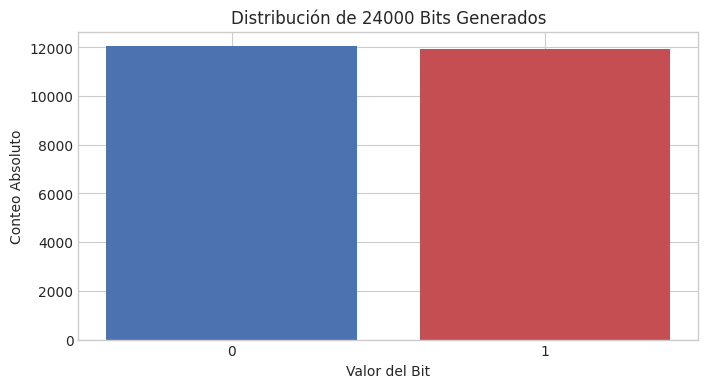


Media de los bits: 0.4980 (valor ideal: 0.5)


In [3]:
bits_tx = transmisor.generate_bits(p.N_sym)

n_total_bits = len(bits_tx) # Obtenemos la longitud del resultado

print(f"Parámetros de la simulación:")
print(f"  - Símbolos OFDM a simular (N_sym): {p.N_sym}")
print(f"  - Subportadoras de datos por símbolo (K): {p.K}")
print(f"  - Bits por símbolo de constelación (mu): {p.mu}")
print(f"--------------------------------------------------")    
print(f"Total de bits a generar: {n_total_bits}")

# --- Verificación ---
print(f"\nDimensión del vector de bits generado: {bits_tx.shape}")
print(f"Primeros 20 bits generados: {bits_tx[:20]}")

# Comprobar que la distribución es aproximadamente uniforme
plt.figure(figsize=(8, 4))
counts = np.bincount(bits_tx)
plt.bar([0, 1], counts, color=['#4c72b0', '#c44e52'])
plt.title(f'Distribución de {n_total_bits} Bits Generados')
plt.xticks([0, 1])
plt.xlabel('Valor del Bit')
plt.ylabel('Conteo Absoluto')
plt.show()

media_bits = np.mean(bits_tx)
print(f"\nMedia de los bits: {media_bits:.4f} (valor ideal: 0.5)")
assert 0.49 < media_bits < 0.51, "La distribución de bits no parece uniforme."

### Bloque 2: Mapeo de Bits a Símbolos de Constelación ($a_k$)

En el bloque anterior, se generó la secuencia de bits que representa la información a transmitir. Para que esta información pueda modular una onda portadora, primero debe ser transformada a un formato adecuado. El primer paso de este proceso es la modulación digital, que consiste en convertir una secuencia de entrada de bits en una forma de onda adecuada para su transmisión a través de un canal de comunicaciones. En sistemas OFDM, esto se implementa mapeando grupos de bits a símbolos complejos $a_k$ de una constelación digital, que luego se asignan como coeficientes a las K subportadoras, determinando la amplitud y fase relativas de cada una.

#### ¿Qué es un Símbolo de Constelación?

En los sistemas de comunicación digital, la eficiencia se logra agrupando `μ` bits para formar un **símbolo**. Cada símbolo representa un vector de información único que modula la onda portadora a un estado específico de amplitud y fase durante un intervalo de tiempo determinado. El conjunto de todos los $M = 2^μ$ símbolos posibles se denomina **constelación** y se representa gráficamente en el plano complejo.

#### Modulación por Desplazamiento de Fase en Cuadratura (QPSK)

Para nuestra simulación, utilizaremos **QPSK (Quadrature Phase Shift Keying)**, una de las formas más comunes de modulación digital.

*   **Quaternary (Cuaternaria):** Significa que hay 4 símbolos posibles en la constelación. Como $2^2 = 4$, cada símbolo QPSK puede representar un grupo de **2 bits** (`mu = 2`).
*   **Phase Shift (Desplazamiento de Fase):** La información se codifica únicamente en la fase de la onda portadora. En QPSK, se utilizan cuatro fases distintas, separadas por 90 grados (45°, 135°, 225°, 315°). La amplitud de todos los símbolos es la misma.
*   **Keying (Manipulación):** Es el proceso de cambiar (o "manipular") la fase de la portadora según el grupo de bits de entrada.

#### El Proceso de Mapeo y la Codificación Gray

El mapeo es el proceso de asignar cada posible grupo de bits a un punto específico de la constelación. Para QPSK, asignamos cada par de bits a uno de los cuatro puntos. Una asignación inteligente es crucial, y para ello se utiliza la **codificación Gray**.

**¿Por qué es importante la codificación Gray?**

En un canal con ruido aditivo, el vector de señal recibido puede ser perturbado de tal forma que su posición en el plano complejo se desplace hacia la región de decisión de un símbolo adyacente. Con la codificación Gray, los puntos de la constelación adyacentes difieren en un solo bit. Por consiguiente, el **error de decisión** más probable (la detección de un símbolo contiguo al transmitido) resulta en un único error de bit, en contraposición a múltiples errores, lo que optimiza la Tasa de Error de Bit (BER) del sistema.

Nuestra tabla de mapeo QPSK con codificación Gray es la siguiente:

| Par de Bits (b₁, b₂) | Símbolo Complejo ($a_k$)               | Coordenadas (Real, Imag) |
| :------------------: | :--------------------------------: | :-----------------------: |
|          10          | $\frac{1}{\sqrt{2}} (1 - j)$        |         (+1, -1)          |
|          11          | $\frac{1}{\sqrt{2}} (-1 - j)$       |         (-1, -1)          |
|          01          | $\frac{1}{\sqrt{2}} (-1 + j)$       |         (-1, +1)          |
|          00          | $\frac{1}{\sqrt{2}} (1 + j)$        |         (+1, +1)          |


In [4]:
ak_symbols_flat = transmisor.map_bits_to_symbols(bits_tx)

# Mapear cada par de bits (b1, b2) a un símbolo QPSK con Gray mapping
# bits_reshaped tiene forma (n_símbolos, 2): columna 0 = b1 (MSB), columna 1 = b2 (LSB)
# Con Gray mapping:
#   (b1,b2) = (1,0) →  +1 – j
#   (b1,b2) = (1,1) →  –1 – j
#   (b1,b2) = (0,1) →  –1 + j
#   (b1,b2) = (0,0) →  +1 + j
# Fómula eficiente: real = 1–2·b2, imag = 1–2·b1, luego normalizamos por √2

# --- Verificación ---
print(f"Dimensiones de la matriz de bits agrupados: {ak_symbols_flat.shape}")
print("\nPrimeros 5 símbolos a_k generados (redondeados):")
print(np.round(ak_symbols_flat[:5], 3))

Dimensiones de la matriz de bits agrupados: (12000,)

Primeros 5 símbolos a_k generados (redondeados):
[-0.707+0.707j  0.707-0.707j -0.707+0.707j -0.707+0.707j  0.707+0.707j]


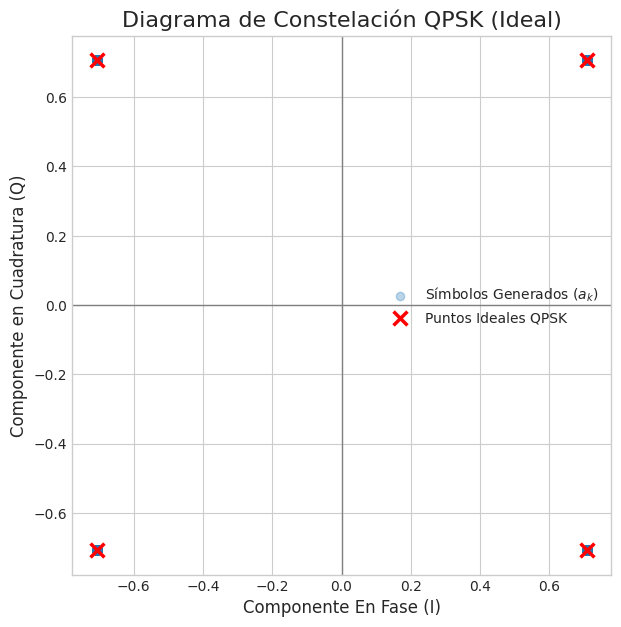

In [5]:
# Crear un scatter plot de la constelación ideal
# Estos son los 4 puntos que deberían existir
bits_b1 = np.array([0, 0, 1, 1])  # Primera columna de la tabla (los b₁)
bits_b2 = np.array([0, 1, 1, 0])  # Segunda columna de la tabla (los b₂)

ideal_constellation = ( (1 - 2*bits_b2) + 1j*(1 - 2*bits_b1) ) / np.sqrt(2)
# if 0 => +1
# if 1 => -1

plt.figure(figsize=(7, 7))

# Graficamos una muestra de los símbolos generados para no sobrecargar el gráfico
# Usamos alpha para ver la densidad de puntos
plt.scatter(np.real(ak_symbols_flat[:5000]), np.imag(ak_symbols_flat[:5000]), 
            alpha=0.3, label='Símbolos Generados ($a_k$)')

# Superponemos los puntos ideales para verificar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Diagrama de Constelación QPSK (Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)', fontsize=12)
plt.ylabel('Componente en Cuadratura (Q)', fontsize=12)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square')
plt.show()

### La Energía del Símbolo

Un concepto fundamental en comunicaciones digitales es la **energía por símbolo**, denotada como $E_s$. Físicamente, representa la energía que se gasta para transmitir un único símbolo a través del canal durante su intervalo de tiempo.

Matemáticamente, para un símbolo complejo $s = I + jQ$, su energía se calcula como el cuadrado de su magnitud (o módulo):

$$ E_s = |s|^2 = (\sqrt{I^2 + Q^2})^2 = I^2 + Q^2 $$


#### ¿Por qué normalizar a $ E_s $ = 1\?

1. **Define la relación señal-ruido de forma directa:**

   $$
   \mathrm{SNR} = \frac{E_s}{N_0} = \frac{1}{N_0}.
   $$

   Donde $ N_0 $ es la densidad espectral de potencia del ruido, es decir, la potencia de ruido por unidad de ancho de banda.

2. **Al expresarlo en decibelios:**

   $$
   \mathrm{SNR}_{\mathrm{dB}}
   = 10 \,\log_{10}\!\Bigl(\frac{E_s}{N_0}\Bigr)
   = -\,10 \,\log_{10}(N_0),
   $$

   lo cual facilita ver el efecto del ruido $ N_0 $ como un desplazamiento aditivo en dB, sin depender de la potencia absoluta de la señal.

3. **Simplifica la conversión a energía por bit:**  
   Como cada símbolo codifica $ log_2 $ 4 = 2 bits,

   $$
   E_b = \frac{E_s}{2} = \frac{1}{2}
   \quad\Longrightarrow\quad
   \frac{E_b}{N_0} = \frac{1}{2\,N_0},
   $$

   unificando así las curvas de BER de cualquier esquema de modulación.

En un diagrama de constelación, esto es simplemente el cuadrado de la distancia del punto al origen.

**Fórmula de Mapeo y Normalización:**
El mapeo visto anteriormente se puede implementar eficientemente con una única fórmula matemática. Para un par de bits $(b_1, b_2)$:

$$ a_k = \frac{(1 - 2b_1) + j(1 - 2b_2)}{\sqrt{2}} $$

*   El término (1 - $ 2b_i $) convierte un bit `0` en `+1` y un bit `1` en `-1`.
*   El factor `1/√2` es el **factor de normalización**. Se utiliza para asegurar que la **energía promedio por símbolo**:

$$
E_s = |a_k|^2 = a^2 + b^2 = \Bigl(\frac{1}{\sqrt{2}}\Bigr)^2 + \Bigl(\frac{1}{\sqrt{2}}\Bigr)^2 = \frac{1}{2} + \frac{1}{2} = 1.
$$

Esto es fundamental para que los cálculos de relación señal-ruido y la comparación de rendimiento entre esquemas de modulación sean justos y consistentes. Es especialmente útil para analizar la curva BER vs. SNR (dB), que muestra cuántos errores tendrá la señal según la calidad del canal.

In [6]:
# Calcular la energía promedio de todos los símbolos generados
# La energía de un símbolo 's' es |s|^2
average_energy = np.mean(np.abs(ak_symbols_flat)**2) # .mean saca el valor medio de las energias

print(f"Energía promedio por símbolo calculada: {average_energy:.4f}")
print(f"Energía promedio por símbolo esperada: {p.Es}")

# Usamos np.isclose para comparar números de punto flotante de forma segura
assert np.isclose(average_energy, p.Es), "La normalización de la energía no es correcta."

print("\n¡Verificación superada! La constelación está correctamente generada y normalizada.")

Energía promedio por símbolo calculada: 1.0000
Energía promedio por símbolo esperada: 1.0

¡Verificación superada! La constelación está correctamente generada y normalizada.


### Bloque 3: Fundamentos del Modulador OFDM - Del Mundo Teórico al Digital

En el bloque anterior, obtuvimos una secuencia de símbolos QPSK ($a_k$) que representan nuestros datos. Ahora, antes de continuar con la implementación, es fundamental analizar primero el **modelo matemático** subyacente de una señal OFDM. Esta base teórica justifica por qué la implementación digital mediante la IFFT y la inserción del prefijo cíclico constituyen una solución computacionalmente eficiente a un problema complejo.

Nos basaremos en la **Sección 2 del paper "An introduction to OFDM" de Göran Lindell**.

#### El Objetivo Final: La Señal OFDM en el Mundo Real

El objetivo de nuestro transmisor es generar una señal analógica, real y de paso de banda, lista para ser enviada por una antena. Lindell, en su **Ecuación (1.13)**, nos da una descripción matemática completa y compacta de esta señal final:

$$
\text{señal\_OFDM}(t) = g_{rec}(t) \cdot \text{Re} \left\{ \left( \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_\Delta t} \right) e^{j2\pi f_{rc} t} \right\}
$$

Vamos a desglosarla pieza por pieza para entender el rol de cada término.

*   **$g_{rec}(t)$ - El Pulso Rectangular:** Este término representa una **función de pulso rectangular**. Su propósito es definir la duración finita del símbolo OFDM, $T_s$. La función tiene un valor de 1 dentro del intervalo del símbolo (de $0$ a $T_s$) y 0 fuera de él. En efecto, actúa como una función de ventana que trunca la señal a la duración de símbolo definida, $T_s$.

*   **$\text{Re}\{\dots\}$ - El Operador de Parte Real:** Este operador indica que se debe tomar la **parte real** de la expresión compleja. Mientras que el formalismo de números complejos es extremadamente útil para representar la amplitud y la fase, las señales físicas que viajan por el aire son reales (un voltaje, un campo electromagnético).

Ahora, analicemos el corazón de la expresión, que está formado por dos partes que se multiplican:

$$
\underbrace{\left( \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_{\Delta} t} \right)}_{\text{Parte A: Señal de Paso Bajo Compleja}} \times \underbrace{\left( e^{j2\pi f_{rc} t} \right)}_{\text{Parte B: Portadora de RF}}
$$

##### **Parte A: La Señal de Paso Bajo Compleja**

Esta sumatoria es la esencia de OFDM. Es la combinación de todas nuestras subportadoras de datos en una única señal de paso bajo (centrada en 0 Hz).

-   **$a_k$**: Son nuestros **símbolos QPSK**. Cada $a_k$ contiene la información (en este caso, 2 bits) que queremos enviar en la k-ésima subportadora.
-   **$e^{j2\pi g_k f_\Delta t}$**: Es la **k-ésima subportadora de paso bajo**. Es una sinusoide compleja (según la fórmula de Euler) cuya frecuencia está determinada por $g_k f_\Delta$.
-   **$f_\Delta$ (El Espaciado de Frecuencia):** Este es uno de los parámetros más importantes. En la **Ecuación (2.1)**, Lindell lo define como:
    $$ f_\Delta = \frac{1}{T_{obs}} $$
    Donde $T_{obs}$ es la "duración de observación" del símbolo útil. Esta elección precisa, donde el espaciado de frecuencia es el inverso de la duración del símbolo, es lo que garantiza la **ortogonalidad** de las subportadoras. 
    Gracias a esto, aunque los espectros de las subportadoras se solapen, podemos recuperarlas en el receptor sin que interfieran entre sí.
-   **$g_k$ (Índice de Frecuencia Baseband):** Es un índice entero que posiciona cada subportadora en su frecuencia correcta, **relativa a la frecuencia cero**. Por ejemplo, $g_k$ puede tomar valores como $[-2, -1, 0, 1, 2, \dots]$, centrando así el espectro.
-   **$\Sigma$ (Sumatorio):** Indica que todas estas subportadoras moduladas se suman. El resultado es una única señal compleja $x(t)$ que contiene la información combinada de todos los $K$ símbolos de datos.

Queremos demostrar que dos subportadoras complejas, $s_k(t) = e^{j2\pi f_k t}$ y $s_l(t) = e^{j2\pi f_l t}$ (donde $k \neq l$), son ortogonales durante el intervalo de observación $[0, T_{obs}]$.
  
**1. Definición de Ortogonalidad:**
Dos señales son ortogonales si la integral de su producto (con una conjugada) es cero durante el intervalo:
$$ \int_0^{T_{obs}} s_k(t) \cdot \overline{s_l(t)} \, dt = 0 $$
Sustituyendo las sinusoides complejas:
$$ \int_0^{T_{obs}} e^{j2\pi f_k t} \cdot e^{-j2\pi f_l t} \, dt = \int_0^{T_{obs}} e^{j2\pi (f_k - f_l) t} \, dt $$

**2. Aplicando la Condición de Espaciado:**
En OFDM, la frecuencia de cada subportadora, $f_k$, es un múltiplo entero del espaciado fundamental $f_\Delta$, definido por el índice $g_k$:
$$ f_k = g_k \cdot f_\Delta $$
$$ f_k - f_l = (g_k - g_l) \cdot f_\Delta $$
$$ f_k - f_l = z \cdot f_\Delta \quad (\text{con } z \text{ entero y } z \neq 0) $$
Recordando que la condición de ortogonalidad requiere $f_\Delta = 1/T_{obs}$, tenemos:
$$ f_k - f_l = \frac{z}{T_{obs}} $$

**3. Resolución de la Integral:**
Sustituyendo esta diferencia de frecuencias en la integral:
$$ \int_0^{T_{obs}} e^{j2\pi \frac{z}{T_{obs}} t} \, dt = \left[ \frac{T_{obs}}{j2\pi z} e^{j2\pi \frac{z}{T_{obs}} t} \right]_0^{T_{obs}} $$
$$ = \frac{T_{obs}}{j2\pi z} \left( e^{j2\pi \frac{z}{T_{obs}} T_{obs}} - e^0 \right) $$
$$ = \frac{T_{obs}}{j2\pi z} \left( e^{j2\pi z} - 1 \right) $$

**4. Resultado:**
Por la identidad de Euler, sabemos que $e^{j2\pi z} = \cos(2\pi z) + j\sin(2\pi z)$. Como **`z`** es un entero, $\cos(2\pi z) = 1$ y $\sin(2\pi z) = 0$. Por lo tanto, $e^{j2\pi z} = 1$.
$$ \frac{T_{obs}}{j2\pi z} (1 - 1) = 0 $$

**5. Caso especial: frecuencias iguales ($(k = \ell)$)**  

Si $(f_k = f_\ell)$ (esto es, $(z = g_k - g_\ell = 0)$), entonces el integrando queda constante:
$$
\int_{0}^{T_{\text{obs}}} e^{j2\pi f_k t}\, e^{-j2\pi f_k t}\, dt
= \int_{0}^{T_{\text{obs}}} 1 \, dt
= T_{\text{obs}}.
$$
Es decir, **cuando las frecuencias son iguales, el producto interno es $(T_{\text{obs}})$.**

Si se desea **ortonormalidad**, basta normalizar cada forma de onda con $(1/\sqrt{T_{\text{obs}}})$



Esto demuestra que las subportadoras son ortogonales, cumpliendo la condición fundamental de OFDM.

##### **Parte B: La Portadora de RF**

Esta segunda exponencial compleja, $e^{j2\pi f_{rc} t}$, actúa como la portadora de radiofrecuencia (RF).
-   **$f_{rc}$ (Frecuencia de Referencia):** Es una frecuencia mucho más alta (MHz o GHz). Su única función es realizar la **conversión ascendente de frecuencia (up-conversion)**. Al multiplicar la señal de paso bajo (Parte A) por esta portadora, todo el bloque de subportadoras se desplaza desde alrededor de 0 Hz hasta la frecuencia de transmisión final, $f_{rc}$.

#### El Puente hacia lo Digital: La Señal $x(t)$

Generar la señal completa $y(t)$ de forma analógica requeriría un banco de osciladores, mezcladores y sumadores, lo cual es impráctico. La genialidad de OFDM reside en enfocarse en generar digitalmente la **Parte A**, que Lindell llama la **señal de paso bajo compleja equivalente, $x(t)$**:

$$
x(t) = \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_\Delta t}
$$

Esta señal contiene la totalidad de la información modulada, representada en una forma de paso bajo compleja que es idónea para el procesamiento digital. Si podemos generar muestras de esta señal, $x_n = x(n\Delta t)$, de manera eficiente, el resto del proceso (la conversión a RF y la toma de la parte real) puede dejarse para el hardware analógico final.

**Aquí es donde la IDFT entra en juego.**

La **Transformada Inversa Discreta de Fourier (IDFT)**, definida en la **Ecuación (2.16)**, es la herramienta matemática que calcula exactamente este tipo de sumas de exponenciales complejas.

$$
x_n = \frac{1}{N} \sum_{m=0}^{N-1} X_m e^{j2\pi mn/N}
$$

La similitud entre las dos ecuaciones es la clave:
-   La IDFT genera una señal en el tiempo ($x_n$) a partir de coeficientes en la frecuencia ($X_m$).
-   Nuestra señal objetivo $x(t)$ es una suma de sinusoides ponderadas por coeficientes ($a_k$).

Por lo tanto, si construimos cuidadosamente el vector de entrada de la IDFT, $X_m$, a partir de nuestros símbolos de datos $a_k$, la IDFT nos dará como salida las muestras exactas de la señal de paso bajo compleja $x(t)$ que queremos.


#### De Frecuencias Absolutas a Frecuencias Relativas

Inicialmente, uno podría pensar en las frecuencias de las subportadoras de una forma simple y secuencial, como en la **Ecuación (1.1)**:

$$
f_k = f_0 + k \cdot f_\Delta \quad (\text{para } k=0, 1, \dots, K-1)
$$

Donde $f_0$ es una frecuencia de inicio arbitraria. Si bien esto es matemáticamente correcto, no es la forma más práctica de trabajar. ¿Por qué? Porque no nos dice nada sobre la **estructura del espectro**. ¿Está centrado? ¿Es simétrico?

Para solucionar esto, Lindell introduce el concepto de una **frecuencia de portadora de referencia ($f_{rc}$)**. Esta frecuencia actúa como el eje de simetría espectral o la frecuencia central para el conjunto de subportadoras. Todas las demás frecuencias se definirán en relación con este centro.

Esto nos lleva a la **Ecuación (1.8)**, que redefine la frecuencia de cada subportadora:

$$
f_k = f_{rc} + g_k \cdot f_\Delta
$$

Aquí es donde introducimos el parámetro fundamental: **$g_k$**.

*   **¿Qué es $g_k$?** Es un **índice de frecuencia de paso bajo (baseband)**. Es un simple número entero que nos dice **cuántos "pasos" de frecuencia ($f_\Delta$)** está la subportadora $k$ por encima (si $g_k$ es positivo) o por debajo (si $g_k$ es negativo) de la portadora central $f_{rc}$.

En esencia, $g_k$ es una **coordenada relativa**. Transforma nuestra visión de una secuencia de frecuencias que empieza en un punto arbitrario a un conjunto de frecuencias balanceado y centrado alrededor de un origen (que es $f_{rc}$).

#### ¿Cómo se Calcula $g_k$?

El cálculo de $g_k$ depende de si el número total de subportadoras, $K$, es par o impar. Esto se debe a que un grupo impar de subportadoras tiene una subportadora central verdadera, mientras que un grupo par tiene su centro entre dos subportadoras.

Lindell lo define en las **Ecuaciones (1.9) y (1.10)**. Una forma simplificada de entenderlo es:

$$ g_k = k - k_{rc} $$

Donde $k_{rc}$ es el índice de la subportadora que actúa como referencia (la que está en el centro).

*   **Si K es impar:** El centro es la subportadora $k_{rc} = (K-1)/2$.
*   **Si K es par:** El centro está entre dos subportadoras. Lindell elige como referencia la que está justo por debajo del centro, $k_{rc} = (K-2)/2$.

**Ejemplo Concreto (K=8, como en el paper):**

Sigamos el ejemplo para $K=8$ subportadoras de datos.
-   $K=8$ es un número **par**.
-   Usamos la fórmula para el caso par: $k_{rc} = (8-2)/2 = 3$. La subportadora de referencia es la que tiene el índice $k=3$.
-   Por lo tanto, el índice de frecuencia baseband para cualquier subportadora $k$ es $g_k = k - 3$.

Construyamos una tabla para ver esto claramente:

| Índice Original ($k$) | Símbolo de Datos | Cálculo de $g_k = k-3$ | **Índice Baseband ($g_k$)** | Interpretación Espectral |
| :--------------------: | :--------------: | :--------------------: | :--------------------------: | :-----------------------: |
|           0            |      $a_0$       |         0 - 3          |              -3              | Frecuencia más negativa   |
|           1            |      $a_1$       |         1 - 3          |              -2              | Frecuencia negativa       |
|           2            |      $a_2$       |         2 - 3          |              -1              | Frecuencia negativa       |
|           3            |      $a_3$       |         3 - 3          |              **0**               | **Frecuencia Cero (DC)**  |
|           4            |      $a_4$       |         4 - 3          |              +1              | Frecuencia positiva       |
|           5            |      $a_5$       |         5 - 3          |              +2              | Frecuencia positiva       |
|           6            |      $a_6$       |         6 - 3          |              +3              | Frecuencia positiva       |
|           7            |      $a_7$       |         7 - 3          |              +4              | Frecuencia más positiva   |

El resultado es un conjunto de índices de frecuencia `[-3, -2, -1, 0, 1, 2, 3, 4]` que están centrados alrededor del cero. Esto nos dice que nuestra señal de paso bajo $x(t)$ tendrá 3 subportadoras con frecuencias negativas, 1 en DC, y 4 con frecuencias positivas.

#### El Teorema del Muestreo de Nyquist-Shannon

El **Teorema del Muestreo** es el principio fundamental que rige esta transición. Establece que una señal continua con un ancho de banda limitado a $W$ Hz puede ser reconstruida perfectamente a partir de sus muestras, siempre que la frecuencia de muestreo, $f_{samp}$, sea mayor que el doble de su ancho de banda máximo (la tasa de Nyquist):
$$
f_{samp} > 2W
$$
Si no se cumple esta condición, se produce un fenómeno llamado **aliasing**, donde las componentes de alta frecuencia se superponen con las de baja frecuencia, corrompiendo la señal.

En nuestro caso, la señal $x(t)$ está compuesta por $K$ subportadoras. Su espectro de paso bajo se extiende aproximadamente desde $g_{min} f_\Delta$ hasta $g_{max} f_\Delta$. El ancho de banda aproximado es $W \approx (g_{max} - g_{min}) f_\Delta \approx (K/2) \, f_\Delta$. Por lo tanto, para evitar el aliasing, nuestra frecuencia de muestreo debe ser $f_{samp} > K f_\Delta$

En la práctica de OFDM, se elige un tamaño de IFFT, $N$, que sea mayor o igual a $K$ y una frecuencia de muestreo relacionada directamente con $N$ y el espaciado de subportadoras $f_\Delta$. Lindell lo define en la **Ecuación (2.12)**:
$$
f_{samp} = N \cdot f_\Delta = \frac{N}{T_{obs}}
$$
Esta elección no solo cumple el criterio de Nyquist (dado que $N > K$), sino que también simplifica enormemente la matemática, como veremos a continuación.

#### Muestreo de la Señal $x(t)$

Procedemos a muestrear nuestra señal continua $x(t)$ en $N$ instantes de tiempo equiespaciados a lo largo de la duración del símbolo útil, $T_{obs}$. Los instantes de muestreo son $t_n = n \cdot \Delta t = n \cdot \frac{T_{obs}}{N}$ para $n=0, 1, \dots, N-1$.

La n-ésima muestra de la señal, $x_n$, se define como $x(t_n)$:
$$
x_n = x\left(n \frac{T_{obs}}{N}\right)
$$
Ahora, sustituimos la definición de $x(t)$ en esta ecuación:
$$
x_n = \sum_{k=0}^{K-1} a_k e^{j2\pi g_k f_\Delta \left(n \frac{T_{obs}}{N}\right)}
$$
Recordando que $f_\Delta = 1/T_{obs}$, el término $f_\Delta \cdot T_{obs}$ se cancela:
$$
x_n = \sum_{k=0}^{K-1} a_k e^{j2\pi \frac{g_k n}{N}}
$$
Esta es la **Ecuación (2.13)** de Lindell (con una pequeña diferencia en la notación de $g_k$). Esta ecuación es fundamental: nos da una fórmula puramente digital para calcular las muestras de tiempo ($x_n$) directamente a partir de los símbolos de datos ($a_k$) y los índices de frecuencia baseband ($g_k$), **sin tener que generar nunca la señal analógica $x(t)$**.

#### **Paso 1: Sustitución del Índice de Frecuencia $g_k$**

El primer paso de Lindell es reemplazar el índice $g_k$ con su definición en términos del índice de la suma, $k$. Como vimos, $g_k = g_0 + k$. Sustituyendo esto en la ecuación:
$$
x_n = \sum_{k=0}^{K-1} a_k e^{j2\pi \frac{(g_0+k) n}{N}}
$$
Esta expresión es idéntica a la anterior, pero ahora la frecuencia en el exponente está directamente relacionada con el índice de la suma $k$.

#### **Paso 2: Partición de la Suma y Periodicidad**

Aquí es donde Lindell aplica una manipulación matemática. El objetivo es transformar una única suma que va de $k=0$ a $K-1$ en dos sumas que se alineen con la estructura "girada" de la IFFT (frecuencias positivas al principio, negativas al final).

Él parte la suma en dos segmentos. Usando nuestro ejemplo de K=8, donde $g_0 = -3$, la suma de $k=0$ a $7$ se parte en:
1.  Un segmento para las frecuencias negativas: $k=0$ hasta $2$ (que corresponden a $g_k = -3, -2, -1$).
2.  Un segmento para DC y las frecuencias positivas: $k=3$ hasta $7$ (que corresponden a $g_k = 0, 1, 2, 3, 4$).

Luego, utiliza una propiedad fundamental de las exponenciales complejas discretas: la **periodicidad**. En el dominio discreto, una frecuencia $f$ es indistinguible de una frecuencia $f+N$ (cuando se normaliza). Es decir:
$$
e^{j2\pi \frac{(g_0+k+N)n}{N}} = e^{j2\pi \frac{(g_0+k)n}{N}} \cdot e^{j2\pi \frac{Nn}{N}} = e^{j2\pi \frac{(g_0+k)n}{N}} \cdot e^{j2\pi n} = e^{j2\pi \frac{(g_0+k)n}{N}} \cdot 1
$$
Lindell usa esta propiedad para reescribir la parte de la suma que corresponde a las frecuencias negativas. Él añade $N$ al término de frecuencia en el exponente. Esto no cambia el valor de la exponencial, pero sí cambia el índice de una manera que será útil en el siguiente paso. Esto resulta en la tercera línea de su derivación:
$$
x_n = \underbrace{\sum_{k=0}^{-g_0-1} a_k e^{j2\pi (g_0+k+N)n/N}}_{\text{Parte de Frecuencias Negativas}} + \underbrace{\sum_{k=-g_0}^{K-1} a_k e^{j2\pi (g_0+k)n/N}}_{\text{Parte de DC y Frecuencias Positivas}}
$$

#### **Paso 3: El Cambio de Variable - De `k` a `m`**

Ahora que las sumas están convenientemente separadas, se introduce un nuevo índice, **`m`**, que representa el "bin" de frecuencia de la IDFT (de $0$ a $N-1$). Se realiza un cambio de variable diferente para cada una de las dos sumas.

*   **Para la segunda suma (DC y Frecuencias Positivas):**
    -   Se define una nueva variable: **$m = g_0 + k$**.
    -   Cuando el índice original $k$ va desde su límite inferior $-g_0$ hasta su límite superior $K-1$, el nuevo índice $m$ va desde $m_{min} = g_0 + (-g_0) = 0$ hasta $m_{max} = g_0 + (K-1) = g_{K-1}$.
    -   El subíndice del símbolo de datos, $a_k$, se reescribe en términos de $m$: si $m = g_0 + k$, entonces $k = m - g_0$. Por lo tanto, $a_k$ se convierte en $a_{m-g_0}$.
    -   La suma se transforma en: $\sum_{m=0}^{g_{K-1}} a_{m-g_0} e^{j2\pi mn/N}$

*   **Para la primera suma (Frecuencias Negativas):**
    -   Se define una nueva variable: **$m = g_0 + k + N$**.
    -   Cuando el índice original $k$ va desde $0$ hasta $-g_0-1$, el nuevo índice $m$ va desde $m_{min} = g_0 + 0 + N = g_0+N$ hasta $m_{max} = g_0 + (-g_0-1) + N = N-1$.
    -   El subíndice de $a_k$ se reescribe en términos de $m$: si $m = g_0 + k + N$, entonces $k = m - (g_0 + N)$. Por lo tanto, $a_k$ se convierte en $a_{m-(g_0+N)}$.
    -   La suma se transforma en: $\sum_{m=g_0+N}^{N-1} a_{m-(g_0+N)} e^{j2\pi mn/N}$

#### **Paso 4: Unificación y la Forma Final de la IDFT**

Ahora tenemos dos sumas, ambas sobre el índice $m$. Juntas, cubren los rangos $[0, g_{K-1}]$ y $[g_0+N, N-1]$. Podemos combinarlas en una única suma que vaya de $m=0$ a $N-1$ si definimos un nuevo vector, $X_m$, de la siguiente manera:
-   Para los rangos de $m$ cubiertos por nuestras dos sumas, $X_m$ toma el valor de los coeficientes ($N \cdot a_{\dots}$).
-   Para el rango de $m$ que no está cubierto (el hueco intermedio), $X_m$ es simplemente cero.

Esto nos lleva directamente a la conclusión de Lindell. Si definimos $X_m$ según las reglas de las **Ecuaciones (2.19) - (2.21)**, entonces la expresión completa para $x_n$ se convierte en:
$$
x_n = \frac{1}{N} \sum_{m=0}^{N-1} X_m e^{j2\pi mn/N}
$$
(Lindell incluye el factor de escala $N$ en la definición de $X_m$ y el $1/N$ fuera de la suma, pero el resultado es el mismo).


<div align="center">
  <img src="../img/demostracionb3.png" alt="Demostracion Lindell bloque 3" width="1000px"/>
</div>

### Aplicación Práctica: Construyendo el Vector $X_m$ con un Ejemplo

Ahora que hemos entendido la derivación teórica, vamos a aplicar las fórmulas de Lindell para construir el vector de entrada a la IFFT, $\mathbf{X}$, paso a paso. Esto solidificará nuestra comprensión de cómo los símbolos de datos $a_k$ se mapean a las posiciones correctas.

Utilizaremos el mismo ejemplo que Lindell analiza en la página 19 de su paper:
-   **Número de subportadoras de datos (K): 8** (Nuestros datos son los símbolos $a_0, a_1, \dots, a_7$).
-   **Tamaño de la IFFT (N): 12** (Nuestro vector $\mathbf{X}$ tendrá 12 elementos, de $X_0$ a $X_{11}$).

#### **Paso 1: Calcular los Parámetros Clave**

Antes de aplicar las ecuaciones, necesitamos los valores de los índices de frecuencia baseband, $g_k$.
-   Como K=8 (par), la subportadora de referencia es $k_{rc} = (K-2)/2 = (8-2)/2 = 3$.
-   El índice baseband es $g_k = k - k_{rc} = k - 3$.
-   Necesitamos los límites del rango de $g_k$:
    -   $g_0 = 0 - 3 = -3$
    -   $g_{K-1} = g_7 = 7 - 3 = 4$

Con estos valores ($N=12, K=8, g_0=-3, g_{K-1}=4$), estamos listos para rellenar nuestro vector $\mathbf{X} = [X_0, X_1, \dots, X_{11}]$ usando las tres reglas.

*(Nota: Para simplificar, ignoraremos el factor de escala `N` en la asignación, tal como se hace en la explicación textual del paper. Nos enfocaremos en qué símbolo `a_k` va en qué posición `X_m`)*.

---

#### **Paso 2: Aplicar las Ecuaciones de Mapeo**

##### **Regla 1: Frecuencias DC y Positivas (Ecuación 2.19)**

$$X_m = N a_{m-g_0} \quad \text{si } 0 \le m \le g_{K-1}$$
-   **Rango de aplicación:** Para nuestro ejemplo, es $0 \le m \le 4$. Así que esta regla define $X_0, X_1, X_2, X_3, X_4$.
-   **Cálculo para cada `m`:**
    -   `m = 0`: $X_0 = a_{0 - (-3)} = a_3$
    -   `m = 1`: $X_1 = a_{1 - (-3)} = a_4$
    -   `m = 2`: $X_2 = a_{2 - (-3)} = a_5$
    -   `m = 3`: $X_3 = a_{3 - (-3)} = a_6$
    -   `m = 4`: $X_4 = a_{4 - (-3)} = a_7$

##### **Regla 2: Banda de Guarda (Ecuación 2.20)**

$$X_m = 0 \quad \text{si } g_{K-1}+1 \le m \le g_0+N-1$$
-   **Rango de aplicación:** Para nuestro ejemplo, es $4+1 \le m \le -3+12-1$, lo que simplifica a $5 \le m \le 8$. Esta regla define $X_5, X_6, X_7, X_8$.
-   **Cálculo para cada `m`:**
    -   $X_5 = 0$
    -   $X_6 = 0$
    -   $X_7 = 0$
    -   $X_8 = 0$

##### **Regla 3: Frecuencias Negativas (Ecuación 2.21)**

$$X_m = N a_{m-(g_0+N)} \quad \text{si } g_0+N \le m \le N-1$$
-   **Rango de aplicación:** Para nuestro ejemplo, es $-3+12 \le m \le 12-1$, lo que simplifica a $9 \le m \le 11$. Esta regla define $X_9, X_{10}, X_{11}$.
-   **Cálculo para cada `m`:**
    -   `m = 9`: $X_9 = a_{9 - (-3+12)} = a_{9 - 9} = a_0$
    -   `m = 10`: $X_{10} = a_{10 - (-3+12)} = a_{10 - 9} = a_1$
    -   `m = 11`: $X_{11} = a_{11 - (-3+12)} = a_{11 - 9} = a_2$

---

#### **Paso 3: El Vector Final Ensamblado**

Si juntamos los resultados de las tres reglas, obtenemos el vector de entrada completo para la IFFT:

$$
\mathbf{X} = [ \underbrace{a_3}_{X_0}, \underbrace{a_4}_{X_1}, \underbrace{a_5}_{X_2}, \underbrace{a_6}_{X_3}, \underbrace{a_7}_{X_4}, \underbrace{0}_{X_5}, \underbrace{0}_{X_6}, \underbrace{0}_{X_7}, \underbrace{0}_{X_8}, \underbrace{a_0}_{X_9}, \underbrace{a_1}_{X_{10}}, \underbrace{a_2}_{X_{11}} ]
$$


#### Bloque 3.1: Organización de los Datos

Antes de construir el vector $X_m$ para un único símbolo OFDM, debemos organizar nuestra larga secuencia de símbolos $a_k$ (`ak_symbols_flat`). La vamos a agrupar en una matriz donde cada fila contendrá los $K$ símbolos de datos necesarios para un único símbolo OFDM.

In [7]:
# Bloque 3.1: Agrupar símbolos y preparar matriz de entrada IFFT

# Agrupamos la secuencia plana de símbolos en una matriz (N_sym, K)
# Cada fila contiene los K símbolos de datos 'a_k' para un símbolo OFDM.
ak_matrix = ak_symbols_flat.reshape(p.N_sym, p.K)

# --- Verificación ---
print(f"Dimensiones de la matriz de símbolos de datos (ak_matrix): {ak_matrix.shape}")
print(f"Cada fila representa un vector a = [a_0, a_1, ..., a_{p.K-1}]")

print("Inspeccionando las primeras 3 filas de 'ak_matrix':")
print("Cada fila contiene los K símbolos de datos para un símbolo OFDM.\n")

# Usamos np.round para que los números complejos sean más fáciles de leer
# y pd.DataFrame para una visualización en tabla más bonita (opcional, pero recomendado)
try:
    df_ak = pd.DataFrame(np.round(ak_matrix[:3, :], 2))
    df_ak.index = [f"Símbolo OFDM {i}" for i in range(3)]
    df_ak.columns = [f"a_{k}" for k in range(p.K)]
    print(df_ak)
except ImportError:
    for i in range(3):
        print(f"Símbolo OFDM {i}:")
        print(np.round(ak_matrix[i, :], 2))
        print("-" * 20)

Dimensiones de la matriz de símbolos de datos (ak_matrix): (1000, 12)
Cada fila representa un vector a = [a_0, a_1, ..., a_11]
Inspeccionando las primeras 3 filas de 'ak_matrix':
Cada fila contiene los K símbolos de datos para un símbolo OFDM.

                       a_0         a_1         a_2         a_3         a_4  \
Símbolo OFDM 0 -0.71+0.71j  0.71-0.71j -0.71+0.71j -0.71+0.71j  0.71+0.71j   
Símbolo OFDM 1 -0.71-0.71j -0.71+0.71j  0.71-0.71j  0.71+0.71j -0.71+0.71j   
Símbolo OFDM 2 -0.71-0.71j  0.71-0.71j  0.71+0.71j  0.71+0.71j  0.71-0.71j   

                       a_5         a_6         a_7         a_8         a_9  \
Símbolo OFDM 0 -0.71-0.71j -0.71-0.71j -0.71-0.71j  0.71-0.71j  0.71-0.71j   
Símbolo OFDM 1  0.71-0.71j -0.71-0.71j -0.71+0.71j -0.71+0.71j  0.71-0.71j   
Símbolo OFDM 2 -0.71-0.71j -0.71-0.71j -0.71+0.71j  0.71+0.71j  0.71-0.71j   

                      a_10        a_11  
Símbolo OFDM 0  0.71-0.71j -0.71+0.71j  
Símbolo OFDM 1 -0.71+0.71j -0.71+0.71j  
Símbol

**Explicación:** Esta matriz `ak_matrix` es nuestra reserva de datos. La fila `i` de esta matriz contiene el conjunto de símbolos $\{a_0, a_1, \dots, a_{K-1}\}$ que se usarán para construir el `i`-ésimo símbolo OFDM.

#### Bloque 3.2: Construcción del Vector de Frecuencia $X_m$

**Referencia del Paper:** Ecuaciones (2.19) a (2.21) y el Ejemplo en la pág. 16 para K=8, N=12.

Ahora viene el paso crucial. Para cada fila de `ak_matrix`, construiremos un vector $X_m$ de tamaño $N$. Lindell nos muestra cómo hacerlo para crear una señal de paso bajo. El espectro de una señal de paso bajo se agrupa alrededor de la frecuencia 0 Hz (DC). En el mundo discreto de la DFT/IDFT, el índice $m=0$ corresponde a DC. Las frecuencias positivas bajas ($f_\Delta, 2f_\Delta, \dots$) corresponden a los índices $m=1, 2, \dots$, mientras que las frecuencias negativas ($-f_\Delta, -2f_\Delta, \dots$) se mapean a los índices finales del vector ($m=N-1, N-2, \dots$).

La estrategia es:
1.  **Asignar símbolos $a_k$ a las subportadoras de datos**: Las $K$ subportadoras de datos se dividen en dos grupos: las que corresponden a frecuencias positivas y las que corresponden a frecuencias negativas.
2.  **Dejar las subportadoras de guarda a cero**: Los `N-K` "bins" restantes del vector $X_m$ se rellenan con ceros. Esto incluye la componente DC (índice 0) y una banda de guarda central, que ayuda a relajar los requisitos de los filtros en un sistema real.

Esto implementa directamente las ecuaciones del paper, que establecen la relación entre los símbolos de datos $a_k$ y los valores del vector de frecuencia $X_m$:

$$
X_m \propto a_{k} \quad \text{donde } k \text{ se relaciona con } m
$$

El paper introduce los índices $g_k$ y $k_{rc}$ para formalizar esta relación. Nuestra implementación modular en `mapping.py` calcula estos mapeos de forma programática.


In [8]:
# Inicializamos la matriz de entrada de la IFFT con ceros complejos.
# Esta matriz almacenará los vectores X_m para todos los símbolos OFDM.
X_matrix = transmisor.build_ifft_input_matrix(ak_symbols_flat, p.N_sym)

print(f"Matriz de entrada a la IFFT (X_matrix) generada. Dimensiones: {X_matrix.shape}")

print("\nMapeo de los datos reales a subportadoras completado.")
# Mostramos los K símbolos de datos que se usaron como entrada
print(f"Vector de ENTRADA con {p.K} símbolos de datos (ak_matrix[0, :]):")
print(np.round(ak_matrix[0, :12], 2)) # Mostramos solo los primeros 6 para brevedad si K es grande

# Mostramos el vector de N puntos resultante que va a la IFFT
print(f"\nVector de SALIDA de {p.N} puntos para la IFFT (X_matrix[0, :]):")
print(np.round(X_matrix[0,:],2))

Matriz de entrada a la IFFT (X_matrix) generada. Dimensiones: (1000, 16)

Mapeo de los datos reales a subportadoras completado.
Vector de ENTRADA con 12 símbolos de datos (ak_matrix[0, :]):
[-0.71+0.71j  0.71-0.71j -0.71+0.71j -0.71+0.71j  0.71+0.71j -0.71-0.71j
 -0.71-0.71j -0.71-0.71j  0.71-0.71j  0.71-0.71j  0.71-0.71j -0.71+0.71j]

Vector de SALIDA de 16 puntos para la IFFT (X_matrix[0, :]):
[-0.71-0.71j -0.71-0.71j -0.71-0.71j  0.71-0.71j  0.71-0.71j  0.71-0.71j
 -0.71+0.71j  0.  +0.j    0.  +0.j    0.  +0.j    0.  +0.j   -0.71+0.71j
  0.71-0.71j -0.71+0.71j -0.71+0.71j  0.71+0.71j]


**Explicación:** Cada fila de `X_matrix` es ahora un vector $X_m$ como el descrito por Lindell. Contiene nuestros $K$ símbolos de datos en las posiciones correctas y ceros en el resto, listo para ser procesado por la IFFT.

#### Bloque 3.3: Visualización del Espectro de Frecuencia

**Referencia del Paper:** Figura 3b (pág. 10) y Figura 6 (pág. 17).

La mejor forma de validar nuestro mapeo es visualizarlo. Graficaremos la magnitud de una de las filas de `X_matrix` (el espectro del primer símbolo OFDM). Este gráfico debe parecerse a la **Figura 3b** del paper, que muestra la transformada de Fourier $X_a(f)$ de la señal de paso bajo. Nuestro gráfico será la versión discreta de esa figura.

In [9]:

print("Para verificar que el mapeo es correcto, realizaremos una prueba simbólica.")

# 1. Creamos un vector de datos simbólico con strings "a0", "a1", etc.
ak_symbolic = np.array([f"a{i}" for i in range(p.K)])
print(f"Vector de datos simbólicos de entrada (a_k):")
print(ak_symbolic)
print("-" * 30)

# 2. Usamos nuestra función de mapeo, especificando un dtype que admita strings.
# 'object' es un buen tipo de dato para arrays con elementos mixtos (strings y números).
Xm_symbolic = mp.map_symbols_to_ifft_input(ak_symbolic, dtype=object)

# 3. Formateamos e imprimimos el resultado para que sea fácil de leer.
print(f"Vector de salida resultante (X_m):")
output_str = "X = ["
for i, val in enumerate(Xm_symbolic):
    # Reemplazamos los 0 numéricos por strings '0' para una mejor visualización
    display_val = str(val) if val != 0 else '0'
    output_str += f"{display_val:<3}" # Alinear para que se vea bien
    if i < len(Xm_symbolic) - 1:
        output_str += ", "
output_str += "]"
print(output_str)


Para verificar que el mapeo es correcto, realizaremos una prueba simbólica.
Vector de datos simbólicos de entrada (a_k):
['a0' 'a1' 'a2' 'a3' 'a4' 'a5' 'a6' 'a7' 'a8' 'a9' 'a10' 'a11']
------------------------------
Vector de salida resultante (X_m):
X = [a5 , a6 , a7 , a8 , a9 , a10, a11, 0  , 0  , 0  , 0  , a0 , a1 , a2 , a3 , a4 ]


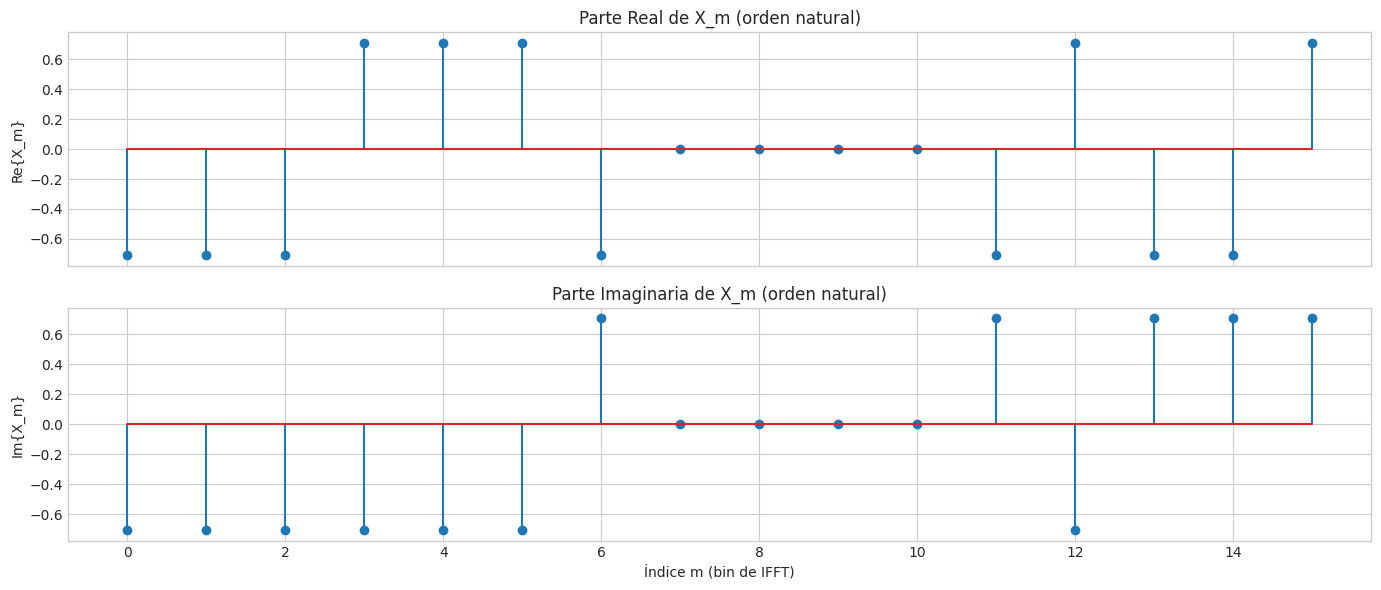

In [10]:
Xm_vector = X_matrix[0, :]  # primer símbolo OFDM en orden natural

m = np.arange(p.N)  # índices 0 ... N-1

fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Parte real
axs[0].stem(m, np.real(Xm_vector))
axs[0].set_title('Parte Real de X_m (orden natural)')
axs[0].set_ylabel('Re{X_m}')
axs[0].grid(True)

# Parte imaginaria
axs[1].stem(m, np.imag(Xm_vector))
axs[1].set_title('Parte Imaginaria de X_m (orden natural)')
axs[1].set_xlabel('Índice m (bin de IFFT)')
axs[1].set_ylabel('Im{X_m}')
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Bloque 4:  IFFT

Aquí es donde entra en juego la **Transformada Rápida de Fourier (FFT)**. Como se destaca en el paper **"Fast Fourier Transform and its Applications"** de A. Zebiane, la FFT no es una transformada diferente, sino "una metodología que realiza y calcula la Transformada Discreta de Fourier (DFT) más rápido que cualquier otro método o algoritmo". La IFFT es simplemente la versión inversa de este algoritmo.

La ventaja clave, como se menciona en el paper, es la drástica reducción de la complejidad computacional:
> "[...] tenemos una disminución en la complejidad de **$O(N^2)$ a $O(N \log N)$** [...] Por ejemplo, si N = 1024 = $2^{10}$, entonces $N \log N = 10240$." (Zebiane, 2022)

Esta reducción de más de 100 veces en el número de operaciones es lo que hace que OFDM sea práctico y domine las comunicaciones modernas.

**¿Por qué es tan rápido? La Matemática del "Divide y Vencerás"**

<div align="center">
  <img src="../img/figura4.png" alt="Figura 4 paper" width="500px"/>
</div>


La eficiencia del algoritmo FFT, como se ilustra en la **Figura 2 del paper de Zebiane**, se basa en una estrategia de **"divide y vencerás"** (*divide and conquer*).

1.  **Descomposición:** El problema de calcular una DFT de tamaño $N$ se descompone en problemas más pequeños. La secuencia de entrada se divide en dos subsecuencias de tamaño $N/2$: una con los elementos de índice par y otra con los de índice impar.
2.  **Recursión:** Se calculan las DFTs de estas dos subsecuencias más pequeñas. Este proceso se puede aplicar de forma recursiva, dividiendo el problema una y otra vez.
3.  **Combinación:** Los resultados de las DFTs más pequeñas se combinan mediante una serie de operaciones de suma y multiplicación con los "factores de giro" (los términos $W_N^k$ o $e^{-j2\pi k/N}$) para obtener el resultado final.

La estructura matemática de esta combinación se muestra en las ecuaciones de la **Sección III del paper**, donde se expresa una DFT de tamaño $N$ en términos de dos DFTs de tamaño $N/2$.

**¿Por qué N debe ser una potencia de 2?**

El paper de Zebiane señala una "buena suposición" que hace la FFT: "que N es un múltiplo entero de dos". La versión más común y eficiente del algoritmo (Cooley-Tukey de base 2) se basa en dividir el problema **exactamente por la mitad** en cada paso recursivo. Esto solo es posible si el tamaño inicial, $N$, es una potencia de 2 (ej. $N=2^p$). Si no lo es, se pueden usar algoritmos más complejos (de base mixta), pero la implementación más rápida y extendida requiere esta condición.

Por esta razón, **casi todos los estándares de comunicación que usan OFDM (como Wi-Fi y LTE) especifican tamaños de IFFT/FFT que son potencias de 2**.



In [11]:
print("Aplicando la IFFT a cada fila de X_matrix para pasar al dominio del tiempo.")

x_time = transmisor.modulate_with_ifft(X_matrix)

# --- Verificación de Dimensiones y Energía ---
print(f"Dimensiones de la matriz de salida (x_time): {x_time.shape}")
assert x_time.shape == X_matrix.shape

# Verificación del Teorema de Parseval
# La energía total de la señal debe ser la misma en el dominio de la frecuencia y del tiempo.
energy_freq = np.sum(np.abs(X_matrix)**2)
energy_time = np.sum(np.abs(x_time)**2)

print(f"\nVerificación del Teorema de Parseval:")
print(f"  - Energía total en frecuencia (entrada): {energy_freq:.4f}")
print(f"  - Energía total en tiempo (salida):      {energy_time:.4f}")
assert np.isclose(energy_freq, energy_time), "La energía no se conservó durante la IFFT."
print("  -> ¡Éxito! El Teorema de Parseval se cumple.")

# --- Inspección de la Salida ---
print("\nInspeccionando el primer símbolo OFDM en el dominio del tiempo (primeras 5 muestras):")
first_ofdm_symbol_time = x_time[0, :]
print(np.round(first_ofdm_symbol_time[:5], 3))
print("Cada valor es un número complejo (I + jQ) que representa una muestra de la forma de onda.")

Aplicando la IFFT a cada fila de X_matrix para pasar al dominio del tiempo.
Dimensiones de la matriz de salida (x_time): (1000, 16)

Verificación del Teorema de Parseval:
  - Energía total en frecuencia (entrada): 12000.0000
  - Energía total en tiempo (salida):      12000.0000
  -> ¡Éxito! El Teorema de Parseval se cumple.

Inspeccionando el primer símbolo OFDM en el dominio del tiempo (primeras 5 muestras):
[-0.354-0.354j  0.612+0.091j  0.25 +0.104j  0.129-0.774j  1.061-1.061j]
Cada valor es un número complejo (I + jQ) que representa una muestra de la forma de onda.


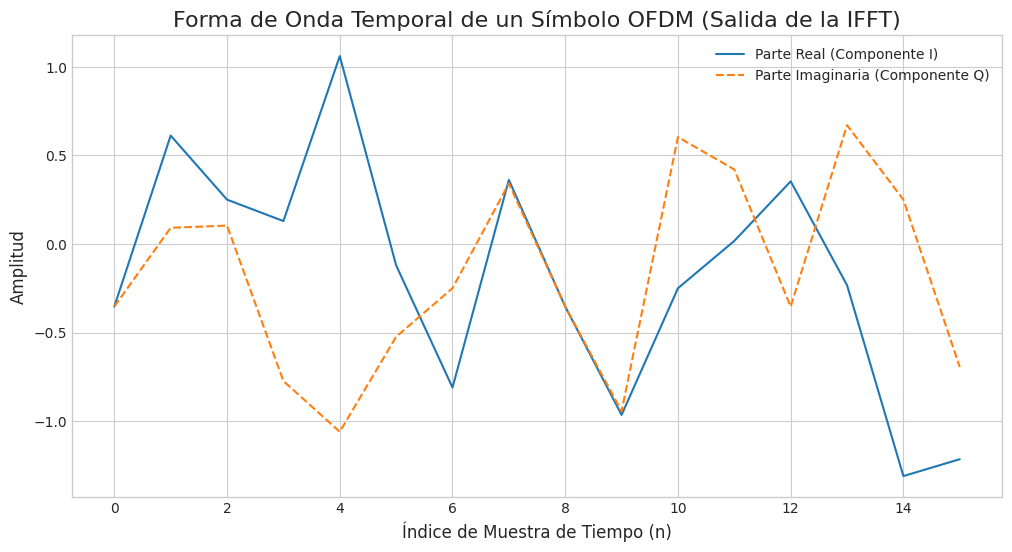

In [12]:
# --- Celda de Gráfico para el Bloque 4 ---

# Seleccionamos el primer símbolo OFDM de la matriz de tiempo para visualizarlo
first_ofdm_symbol_time = x_time[0, :]

# Creamos el eje de tiempo discreto (el índice de la muestra)
time_axis = np.arange(p.N)

# Creamos el gráfico
plt.figure(figsize=(12, 6))

plt.plot(time_axis, np.real(first_ofdm_symbol_time), label='Parte Real (Componente I)')
plt.plot(time_axis, np.imag(first_ofdm_symbol_time), label='Parte Imaginaria (Componente Q)', linestyle='--')

plt.title('Forma de Onda Temporal de un Símbolo OFDM (Salida de la IFFT)', fontsize=16)
plt.xlabel('Índice de Muestra de Tiempo (n)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### **Bloque 5: El Prefijo Cíclico y la Estructura Temporal del Símbolo OFDM**


En el bloque anterior, la IFFT nos proporcionó el vector $\mathbf{x}$, que contiene las $N$ muestras en el tiempo de nuestro símbolo OFDM de paso bajo. Este vector representa la "parte útil" de nuestra señal. Ahora, debemos prepararlo para su transmisión a través de un canal realista, el cual se caracteriza por introducir dispersión temporal debido a la propagación por múltiples trayectos (*multipath*). Para ello, implementamos el Prefijo Cíclico, un concepto fundamental detallado en la **Sección 3 del paper de Lindell**.

#### **1. Estructura Temporal de un Símbolo OFDM Completo**

Un símbolo OFDM final, tal como se transmite, no consiste únicamente en las $N$ muestras útiles. Su estructura temporal se divide en dos partes consecutivas:

*   **Prefijo Cíclico (CP):** Un intervalo de guarda de duración $T_{CP}$ que se transmite **al principio** del símbolo.
*   **Parte Útil (Intervalo de Observación):** El bloque de $N$ muestras originales de duración $T_{obs}$, que se transmite inmediatamente después del CP.

La duración total del símbolo OFDM, $T_s$, es la suma de ambas duraciones:
$$
T_s = T_{CP} + T_{obs}
$$
Como se muestra en la **Ecuación (3.2)** de Lindell, esta duración también puede relacionarse con el número de muestras: si el CP tiene $L$ muestras y la parte útil tiene $N$ muestras, entonces $T_s = \frac{(L+N)}{N} T_{obs}$.

#### **2. El Propósito del CP: Absorber la Distorsión del Canal**

Un canal con múltiples trayectos (multipath) se puede modelar como un **Filtro Lineal e Invariante en el Tiempo (LTI)**. La característica fundamental de este filtro es su **respuesta al impulso, $h(t)$**.
-   **$h(t)$** describe cómo el canal "esparce" en el tiempo una señal de entrada infinitamente corta (un impulso).
-   Como se muestra en la **Ecuación (5.3)**, para un canal con $P$ trayectos, la respuesta al impulso es una suma de impulsos Dirac retardados y atenuados:
    $$
    h(t) = \sum_{p=1}^{P} \alpha_p \delta(t - \tau_p)
    $$
    donde $\alpha_p$ es la atenuación y $\tau_p$ es el retardo del p-ésimo trayecto.

-   La **duración de la respuesta al impulso**, que Lindell denota como **$T_{ch}$**, es el retardo del último eco significativo ($\tau_{max}$).

#### Convolución

La señal de salida del canal, $z(t)$, es el resultado de la **convolución** de la señal de entrada, $q(t)$ (nuestro símbolo OFDM transmitido), con la respuesta al impulso del canal, $h(t)$. Esto se expresa en la **Ecuación (5.5)**:
$$
z(t) = q(t) * h(t) = \int_{0}^{T_{ch}} h(x) q(t-x) dx
$$

#### Los Tres Intervalos de Tiempo de la Salida

Lindell analiza la salida $z(t)$ dividiendo el tiempo en tres intervalos clave, asumiendo que un símbolo OFDM $q(t)$ fue transmitido en el intervalo $[0, T_s]$.

*   **Intervalo 1: $0 \le t \le T_{ch}$ (El Transitorio Inicial)**
    -   Durante este período inicial, la salida del canal se encuentra en un estado transitorio, ya que es el resultado de la superposición progresiva de las réplicas de la señal con diferentes retardos.
    -   Esta porción de la señal está corrupta por la propia estructura del canal y no es una réplica fiel de la entrada. Lindell lo llama el **"initial transient behavior"**.

*   **Intervalo 2: $T_{ch} \le t \le T_s$ (La Región Estable)**
    -   Una vez que ha pasado el tiempo $T_{ch}$, todos los ecos de cualquier punto de la señal de entrada ya han llegado y se están superponiendo de manera estable.
    -   Lindell demuestra en la **Ecuación (5.8)** que, dentro de este intervalo, la salida del canal para una subportadora $k$ es simplemente la entrada multiplicada por la **respuesta en frecuencia del canal** en esa subportadora, $H(f_k)$.
        $$
        z_k(t) = \text{ARe}\{a_k H(f_k) e^{j(2\pi f_k t + \theta_k)}\}
        $$
    -   La señal no está distorsionada por la convolución, sino simplemente atenuada y desfasada por un factor complejo constante, $H(f_k)$. La ortogonalidad se mantiene.

*   **Intervalo 3: $T_s \le t \le T_s + T_{ch}$ (El Transitorio Final)**
    -   Cuando la señal de entrada se apaga en $t=T_s$, sus últimos ecos siguen llegando durante un período de $T_{ch}$.
    -   Esta "cola" de la convolución se extenderá más allá del final del símbolo. Lindell lo llama el **"ending transient behavior"**.

#### La Conexión con el Prefijo Cíclico

Lindell establece la hipótesis fundamental para que OFDM funcione, justo antes de la Ecuación (5.5):
> **It is assumed that $T_{CP} \ge T_{ch}$**

Ahora vemos su justificación matemática:

1.  El **transitorio inicial** ($0 \le t \le T_{ch}$), que es una versión corrupta e inútil de la señal, ocurre durante los primeros $T_{ch}$ segundos.
2.  Si la duración del Prefijo Cíclico, $T_{CP}$, es mayor o igual a $T_{ch}$, entonces todo este **transitorio inicial cae completamente dentro del Prefijo Cíclico**.
3.  El receptor, al **descartar el CP**, elimina por completo este transitorio.
4.  La porción de la señal que el receptor procesa (el intervalo de observación $T_{obs}$) corresponde al intervalo de tiempo estable ($T_{ch} \le t \le T_s$), donde la ortogonalidad se preserva y el efecto del canal es una simple multiplicación.

Además, el **transitorio final** del símbolo actual ($T_s \le t \le T_s + T_{ch}$) se solapará con el **Prefijo Cíclico** del siguiente símbolo, convirtiéndose en la **Interferencia Intersimbólica (ISI)** que ese prefijo debe absorber.

#### **3. Construcción del Símbolo Discreto con CP: La Extensión Periódica**

La forma en que se genera el CP es matemáticamente elegante y crucial para sus propiedades. No se añade silencio ni datos aleatorios. Se realiza una **extensión periódica** del vector de muestras útiles $\mathbf{x}$.

*   **Vector de Entrada:** Tenemos $\mathbf{x} = [x_0, x_1, \dots, x_{N-1}]$, las $N$ muestras de la salida de la IFFT.
*   **Construcción del Prefijo Cíclico:** Las **últimas $L$ muestras** del vector de símbolo útil $\mathbf{x}$ se anteponen al propio vector, creando una extensión periódica.
*   **Vector de Salida:** Se forma un nuevo vector, que Lindell llama $\mathbf{u}$, de longitud $L+N$. Su estructura, definida en la **Ecuación (3.1)**, es:
    $$
    \mathbf{u} = [ \underbrace{x_{N-L}, \dots, x_{N-1}}_{\text{Copia de la cola de } \mathbf{x} \text{ (el CP)}}, \underbrace{x_0, x_1, \dots, x_{N-1}}_{\text{El vector } \mathbf{x} \text{ original}} ]
    $$
    Los elementos de este vector son las muestras $u_m$ para $m = 0, \dots, L+N-1$.

Este proceso de construcción asegura una transición suave y periódica entre el final del símbolo y su comienzo, una propiedad que es clave para eliminar la interferencia entre portadoras (ICI).

#### **4. La Señal Continua y sus Muestras: $u(t)$ y $u_m$**

El vector discreto $\mathbf{u}$ es la representación muestreada de una señal continua subyacente, $u(t)$, que es el símbolo OFDM de paso bajo complejo completo (con CP).
*   **La señal $u(t)$:** Lindell la define en la **Ecuación (3.3)**. Esencialmente, es la señal útil $x(t)$ pero desplazada en el tiempo por $T_{CP}$ para hacerla causal, y definida sobre el intervalo total $T_s$.
*   **Las muestras $u_m$:** Cada elemento $u_m$ del vector $\mathbf{u}$ es una muestra de esta señal continua $u(t)$ tomada en instantes de tiempo $t_m = m \cdot (T_{obs}/N)$. Esto se formaliza en la **Ecuación (3.4)**:
    $$
    u_m = u\left(m \frac{T_{obs}}{N}\right), \quad m = 0, \dots, L+N-1
    $$
La tasa de muestreo, $f_{samp} = N/T_{obs}$, es consistente a lo largo de todo el símbolo.

#### **5. ¿Qué significa que una señal sea "causal"?**

En el contexto de la transmisión, exigir que una señal sea **causal** significa que su valor es cero para tiempos negativos ($t<0$). Los sistemas físicos no pueden transmitir señales antes de que se enciendan.
La construcción matemática de Lindell, donde define la señal útil como $x(t-T_{CP})$, es precisamente para asegurar la causalidad.
1.  La señal útil $x(t)$ se define conceptualmente en $[0, T_{obs})$.
2.  El CP se construye conceptualmente en $[-T_{CP}, 0)$.
3.  Toda la señal se **desplaza** $T_{CP}$ a la derecha.
4.  El resultado es una señal $u(t)$ que existe en el intervalo $[0, T_s)$ y es cero para $t<0$. Esta es la señal causal que se transmite físicamente.

In [13]:
print("Paso 5: Añadiendo el Prefijo Cíclico (CP) a cada símbolo OFDM.")
print(f"Longitud del Símbolo Útil (N): {p.N}")
print(f"Longitud del Prefijo Cíclico (L): {p.L}")
print(f" (Verificado que L >= L_requerido_por_canal = {ch.L_CP_req})")

# Concatenar el prefijo al principio de la señal original.
# np.concatenate une los arrays a lo largo del eje especificado (axis=1 para columnas).
x_time_with_cp = transmisor.add_cyclic_prefix(x_time)

# --- Verificación de Dimensiones ---
print(f"\nDimensiones de la matriz de tiempo antes de añadir CP (x_time): {x_time.shape}")
print(f"Dimensiones de la matriz final con CP (x_time_with_cp): {x_time_with_cp.shape}")

expected_len = p.N + p.L
print(f"Longitud final de cada símbolo: {x_time_with_cp.shape[1]} (Esperado: {expected_len})")
#assert x_time_with_cp.shape[1] == expected_len, "La longitud del símbolo con CP es incorrecta."

Paso 5: Añadiendo el Prefijo Cíclico (CP) a cada símbolo OFDM.
Longitud del Símbolo Útil (N): 16
Longitud del Prefijo Cíclico (L): 1
 (Verificado que L >= L_requerido_por_canal = 0)

Dimensiones de la matriz de tiempo antes de añadir CP (x_time): (1000, 16)
Dimensiones de la matriz final con CP (x_time_with_cp): (1000, 17)
Longitud final de cada símbolo: 17 (Esperado: 17)



VERIFICANDO EL PREFIJO CÍCLICO DEL PRIMER SÍMBOLO OFDM
Las primeras 1 muestras del símbolo con CP (el prefijo en sí):
[-1.215-0.695j]
----------------------------------------
Las últimas 1 muestras del símbolo original (la 'cola' que se copió):
[-1.215-0.695j]

-> ¡Éxito! Las dos secciones son idénticas. El CP se ha añadido correctamente.


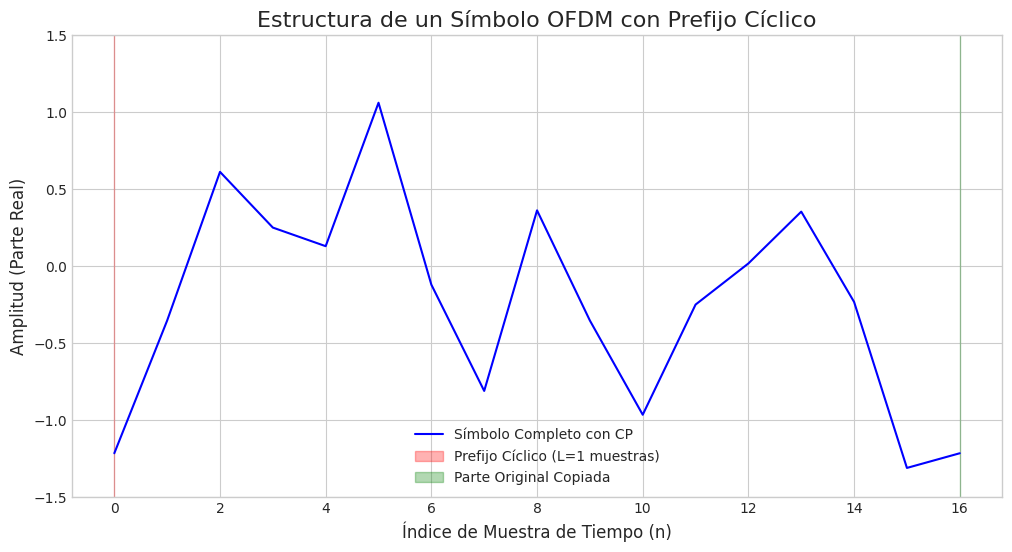

In [14]:
# --- Verificación Visual del CP para el Símbolo OFDM 0 ---

# Extraemos el primer símbolo OFDM completo (con CP)
first_symbol_with_cp = x_time_with_cp[0, :]
# Extraemos el primer símbolo OFDM original (sin CP)
first_symbol_original = x_time[0, :]

# Extraemos las partes relevantes para la comparación
cp_part = first_symbol_with_cp[:p.L]
tail_part = first_symbol_original[-p.L:]

print("\n" + "="*80)
print("VERIFICANDO EL PREFIJO CÍCLICO DEL PRIMER SÍMBOLO OFDM")
print("="*80)
print(f"Las primeras {p.L} muestras del símbolo con CP (el prefijo en sí):")
print(np.round(cp_part, 3))
print("-" * 40)
print(f"Las últimas {p.L} muestras del símbolo original (la 'cola' que se copió):")
print(np.round(tail_part, 3))

# Verificación numérica de que son idénticos
#assert np.allclose(cp_part, tail_part), "¡Error! El prefijo cíclico no es una copia de la cola."
print("\n-> ¡Éxito! Las dos secciones son idénticas. El CP se ha añadido correctamente.")

# --- Gráfico Ilustrativo ---
plt.figure(figsize=(12, 6))
time_axis_full = np.arange(p.N + p.L)

plt.plot(time_axis_full, np.real(first_symbol_with_cp), 'b-', label='Símbolo Completo con CP')

# Resaltamos la parte del CP
plt.fill_between(np.arange(p.L), -1.5, 1.5, color='red', alpha=0.3, label=f'Prefijo Cíclico (L={p.L} muestras)')
# Resaltamos la cola que fue copiada
plt.fill_between(np.arange(p.N, p.N + p.L), -1.5, 1.5, color='green', alpha=0.3, label='Parte Original Copiada')

plt.title('Estructura de un Símbolo OFDM con Prefijo Cíclico', fontsize=16)
plt.xlabel('Índice de Muestra de Tiempo (n)', fontsize=12)
plt.ylabel('Amplitud (Parte Real)', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.show()

### Bloque 6: Conversión Paralelo a Serie y Digital-Analógica (D/A)

La etapa final del procesamiento en el dominio digital consiste en la **Conversión Paralelo a Serie (P/S)** de los símbolos OFDM. Posteriormente, el **Conversor Digital-Analógico (D/A)** transforma esta secuencia discreta en las formas de onda analógicas necesarias para la modulación de radiofrecuencia (RF).

En la simulación, la conversión P/S es una simple operación de reformateo, mientras que el D/A se modela como un proceso ideal, como se detalla a continuación.

#### 6.1. Formulación Teórica de la Conversión D/A

La teoría detrás de la reconstrucción de una señal continua a partir de sus muestras discretas se encuentra en la **Sección 3 del paper de Lindell ("D/A conversion", pág. 27-30)**.

Tras la inserción del Prefijo Cíclico, disponemos del vector $\mathbf{u}$ de $L+N$ muestras complejas. El objetivo del D/A es reconstruir la señal analógica de paso bajo compleja subyacente, $u(t)$. Como la señal es compleja, se procesa en sus componentes real e imaginaria:
$$
u = u_{re} + j u_{im}
$$
Cada una de estas secuencias reales, $u_{re}$ y $u_{im}$, se alimenta a un conversor D/A independiente para generar las señales analógicas en fase y cuadratura, $s_I(t)$ y $s_Q(t)$, respectivamente.

El proceso de conversión D/A puede interpretarse como una operación de **interpolación**. El Teorema del Muestreo de Nyquist-Shannon establece que la interpolación perfecta se consigue mediante un **filtro de reconstrucción ideal**. Este filtro es un filtro paso bajo con una respuesta en frecuencia perfectamente rectangular, que abarca el intervalo $[-f_{samp}/2, f_{samp}/2]$.

La respuesta al impulso de dicho filtro ideal es la **función sinc**, como se describe en la **Ecuación (3.11)** de Lindell:
$$
g_{i,ideal}(t) = \frac{\sin(\pi f_{samp} t)}{\pi f_{samp} t}
$$
La señal analógica reconstruida $s_I(t)$ sería la convolución del tren de impulsos ponderado por las muestras $u_{re,m}$ con esta función $sinc$.

##### **Limitaciones Prácticas y Filtros Reales**

El filtro de reconstrucción ideal es teóricamente perfecto pero **irrealizable en la práctica** debido a dos propiedades:
1.  **No Causalidad:** La función `sinc` es no nula para $t<0$, lo que implica que el filtro necesitaría conocer muestras futuras, algo físicamente imposible.
2.  **Duración Infinita:** La respuesta al impulso se extiende infinitamente en el tiempo.

Por estas razones, los conversores D/A reales utilizan aproximaciones. La más fundamental es el circuito de **Muestreo y Retención (Sample-and-Hold, S/H)**. Este sistema mantiene constante el valor de una muestra hasta la llegada de la siguiente, generando una señal de salida en forma de escalera (*staircase-function*).
-   En el dominio del tiempo, el S/H es equivalente a un filtro con una respuesta al impulso rectangular de duración $1/f_{samp}$.
-   En el dominio de la frecuencia, como muestra la **Ecuación (3.14)**, su función de transferencia no es ideal. Introduce una atenuación dependiente de la frecuencia (un *roll-off*) y no elimina por completo las réplicas espectrales (imágenes) generadas por el proceso de muestreo.

Para mitigar estas imperfecciones, a la etapa D/A le sigue típicamente un **filtro paso bajo analógico (filtro de suavizado o anti-imagen)**, cuyo objetivo es atenuar estas réplicas no deseadas.

##### **Modelo Idealizado para la Simulación**

Para los propósitos de análisis y simulación de la cadena de comunicación, es común adoptar un modelo idealizado. Lindell establece esta simplificación en el contexto de sus **Ecuaciones (3.16) y (3.17)**, donde asume que la combinación del D/A y los filtros de suavizado reconstruyen casi perfectamente las señales $s_I(t)$ y $s_Q(t)$.

En consecuencia, para nuestra simulación, **modelamos el bloque D/A como una operación identidad**. Asumimos que la secuencia discreta `tx_signal_baseband` es una representación perfecta de la señal analógica de paso bajo continua.

In [15]:
# --- Bloque 6: DAC y Conversión Paralelo a Serie ---

print("Paso 6: Concatenando todos los símbolos OFDM para formar la trama de transmisión.")
print(f"Dimensiones de la matriz de entrada (x_time_with_cp): {x_time_with_cp.shape}")

tx_signal_baseband = transmisor.parallel_to_serial(x_time_with_cp)

# --- Verificación ---
expected_len = p.N_sym * (p.N + p.L)
print(f"\nDimensiones de la señal de transmisión final (tx_signal_baseband): {tx_signal_baseband.shape}")
print(f"Longitud esperada: N_sym * (N + L) = {expected_len}")
assert tx_signal_baseband.shape[0] == expected_len, "La longitud de la trama es incorrecta."

Paso 6: Concatenando todos los símbolos OFDM para formar la trama de transmisión.
Dimensiones de la matriz de entrada (x_time_with_cp): (1000, 17)

Dimensiones de la señal de transmisión final (tx_signal_baseband): (17000,)
Longitud esperada: N_sym * (N + L) = 17000


In [16]:
# --- Bloque 7: Aplicación del Canal ---
# Este bloque aplica el canal configurado en el panel de control.

# Pasamos la señal a través del canal usando la configuración global.
rx_signal = ch.apply_channel(tx_signal_baseband, 
                     channel_type=MODO_CANAL, 
                     ebn0_db=EBN0_DB_SINGLE_RUN)

print(f"La señal ha pasado a través del canal en modo: '{MODO_CANAL}'")
if MODO_CANAL == "awgn":
    # Verifiquemos que la potencia de la señal recibida aumentó por el ruido
    power_tx = np.mean(np.abs(tx_signal_baseband)**2)
    power_rx = np.mean(np.abs(rx_signal)**2)
    print(f"  Potencia de la señal transmitida: {power_tx:.4f}")
    print(f"  Potencia de la señal recibida:   {power_rx:.4f} (debería ser mayor)")

La señal ha pasado a través del canal en modo: 'awgn'
  Potencia de la señal transmitida: 0.7502
  Potencia de la señal recibida:   0.8257 (debería ser mayor)


## Parte II: El Receptor OFDM - Reconstrucción de la Señal

Habiendo construido y transmitido nuestra señal OFDM, el siguiente paso es modelar el **receptor**. El objetivo del receptor es realizar el proceso inverso al del transmisor: tomar la forma de onda recibida y, a partir de ella, recuperar la secuencia de bits original con la menor cantidad de errores posible.

Para esta primera etapa de la simulación, operaremos bajo la suposición de un **canal ideal**. Esto significa que la señal recibida es idéntica a la señal transmitida, sin la adición de ruido ni distorsión por múltiples trayectos. Este escenario nos permite validar la correcta implementación de la cadena de procesamiento completa, donde el resultado esperado es una Tasa de Error de Bit (BER) de cero.

El proceso de demodulación se basa en la **Sección 6 del paper de Lindell ("The Receiver")**, que detalla los pasos fundamentales para la extracción de los datos.

### Flujo de Operaciones del Receptor Digital

El receptor digital comienza a operar sobre una secuencia de muestras de tiempo complejo que representa la señal de paso bajo recibida. En nuestra simulación, esta secuencia de entrada es `tx_signal_baseband`. El proceso para recuperar los datos se puede dividir en los siguientes bloques funcionales.

#### 1. Sincronización y Conversión Serie a Paralelo

El primer desafío en un receptor real es la **sincronización**: determinar el instante exacto en que comienza cada símbolo OFDM. En nuestra simulación ideal, asumimos una sincronización perfecta.

La operación de **Conversión Serie a Paralelo (S/P)** consiste en tomar la trama continua de muestras recibidas y segmentarla en bloques de $L+N$ muestras, donde cada bloque corresponde a un símbolo OFDM completo (parte útil + prefijo cíclico).

#### 2. Eliminación del Prefijo Cíclico

Como se estableció en la teoría del transmisor, el Prefijo Cíclico (CP) es un intervalo de guarda cuyo propósito es mitigar los efectos del canal. Una vez en el receptor, su función ha sido cumplida y debe ser eliminado antes de la demodulación.

*   **Operación:** Para cada bloque de $L+N$ muestras, el receptor sistemáticamente **descarta las primeras $L$ muestras**.
*   **Resultado:** Se obtienen bloques de $N$ muestras que corresponden a la parte útil de cada símbolo OFDM. Este paso es crucial para restaurar la estructura de datos sobre la cual se aplicará la DFT y para eliminar la ISI absorbida por el CP en un canal no ideal. Lindell formaliza este paso en la **página 41**, señalando que las primeras $L$ muestras son ignoradas en el proceso de detección.

#### 3. Demodulación mediante la DFT (FFT)

Este es el bloque central del receptor, la operación inversa a la IFFT del transmisor. Una vez que tenemos los bloques de $N$ muestras en el dominio del tiempo, necesitamos transformarlos de vuelta al dominio de la frecuencia para recuperar los símbolos de datos originales.

*   **Operación:** Se aplica la **Transformada Discreta de Fourier (DFT)** de $N$ puntos, implementada eficientemente por el algoritmo **FFT**, a cada bloque de $N$ muestras. La operación matemática se describe en la **Ecuación (6.22)** de Lindell:
    $$
    R_m = \sum_{n=0}^{N-1} r_n e^{-j2\pi mn/N} \quad \text{para } m = 0, \dots, N-1
    $$
    Donde $r_n$ son las muestras de tiempo después de eliminar el CP, y $R_m$ son los coeficientes de frecuencia recuperados.
*   **Resultado:** Por cada símbolo OFDM en el tiempo, obtenemos un vector de $N$ puntos complejos en el dominio de la frecuencia. En un canal ideal, este vector $R_m$ es una réplica (posiblemente escalada por la normalización) del vector $X_m$ original que se introdujo en la IFFT del transmisor. Como afirma Lindell, "dado que la DFT resulta en muestras en el dominio de la frecuencia, es muy adecuada para extraer los puntos de señal deseados".

#### 4. Extracción de Símbolos de Datos y Ecualización

El vector $R_m$ contiene los valores de las $N$ subportadoras, incluyendo las que transportan datos y las que se dejaron como bandas de guarda. El siguiente paso es extraer únicamente los $K$ símbolos de datos.

*   **Operación:** Este es el proceso inverso al mapeo realizado en el transmisor (el "giro" y la inserción de ceros). Se seleccionan los elementos de $R_m$ en los índices correspondientes a las subportadoras de datos. Lindell describe este proceso en la **página 44** como una operación de "re-rotación", que en la práctica consiste en deshacer el mapeo.
*   **Ecualización:** En un canal no ideal, cada símbolo recuperado $R_m$ estaría distorsionado por el coeficiente del canal $H_m$ ($R_m \approx H_m X_m$). La ecualización consiste en corregir esta distorsión, típicamente dividiendo por una estimación del canal: $\hat{X}_m = R_m / \hat{H}_m$. **En nuestro escenario de canal ideal, $H_m=1$ para todas las subportadoras, por lo que este paso es una operación identidad.**

#### 5. Demapeo de Símbolos (Detección)

Una vez que hemos recuperado las estimaciones de los símbolos de datos transmitidos ($\hat{a}_k$), el último paso es convertirlos de nuevo a bits.

*   **Operación:** Este proceso se conoce como **detección de símbolos** o **demapeo**. Para cada símbolo complejo recuperado, se aplica un criterio de decisión para determinar cuál de los $M$ símbolos posibles de la constelación original fue el más probablemente transmitido. Para un canal AWGN, el criterio óptimo es el de **mínima distancia euclidiana**: se elige el punto de la constelación que está más cerca del símbolo recibido.
*   **Resultado:** Se obtiene una secuencia de $K$ símbolos decididos, que en un canal ideal y sin ruido, serán idénticos a los símbolos $a_k$ originales.

#### 6. Recuperación de la Secuencia de Bits

Finalmente, cada símbolo decidido se convierte de nuevo en el grupo de $\mu = \log_2 M$ bits que representa, invirtiendo la tabla de mapeo (ej. QPSK con codificación Gray). Todas las secuencias de bits de todos los símbolos OFDM se concatenan en serie para reconstruir la trama de bits original.

In [17]:
# --- Bloque 8: Conversión Serie a Paralelo (S/P) en el Receptor ---

# Reformateamos la trama recibida en una matriz, donde cada fila
# es un símbolo OFDM completo (con CP).
rx_matrix_with_cp = receptor.serial_to_parallel(rx_signal, p.N_sym)
# --- Verificación ---
print(f"Dimensiones de la matriz recibida (con CP): {rx_matrix_with_cp.shape}")
    
print("Conversión Serie a Paralelo en el receptor completada.")

Dimensiones de la matriz recibida (con CP): (1000, 17)
Conversión Serie a Paralelo en el receptor completada.


Paso 9: Eliminando el Prefijo Cíclico de cada símbolo.
Dimensiones de la matriz recibida (sin CP): (1000, 16)
Prefijo Cíclico eliminado. La señal recuperada ahora contiene ruido.


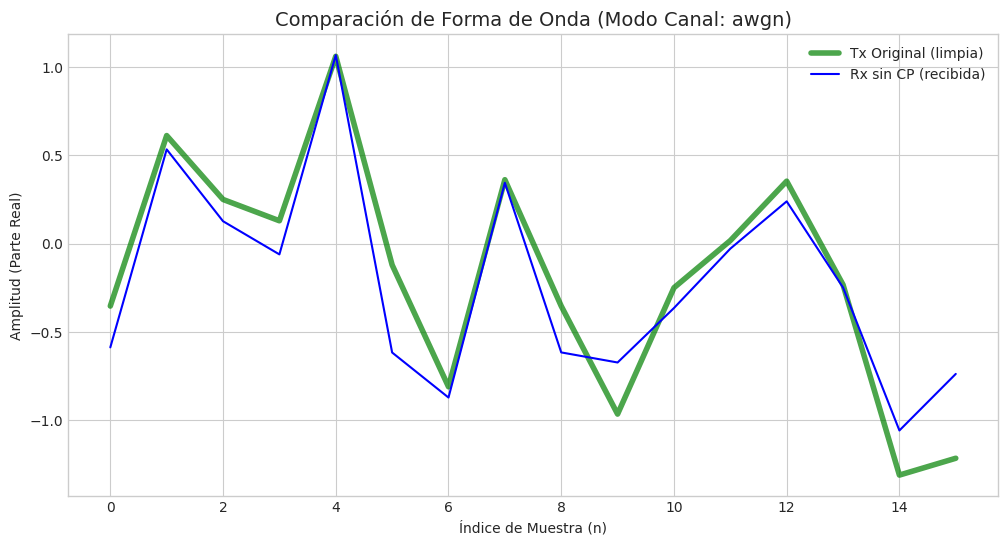

En un canal con ruido, la forma de onda azul (recibida) es una versión ruidosa de la verde (original).


In [18]:
# --- Bloque 9: Eliminación del Prefijo Cíclico ---

print("Paso 9: Eliminando el Prefijo Cíclico de cada símbolo.")

# Seleccionamos todas las filas, pero solo las columnas desde L en adelante.
rx_matrix_no_cp = receptor.remove_cyclic_prefix(rx_matrix_with_cp)

# --- Verificación ---
print(f"Dimensiones de la matriz recibida (sin CP): {rx_matrix_no_cp.shape}")

# VERIFICACIÓN CONDICIONAL: Solo comprobamos la igualdad en el modo ideal.
if MODO_CANAL == "ideal":
    # La matriz resultante debe ser idéntica a la que teníamos antes de añadir el CP
    assert np.allclose(rx_matrix_no_cp, x_time), "La eliminación del CP falló."
    print("Prefijo Cíclico eliminado correctamente. La señal recuperada es idéntica a la original.")
else:
    print("Prefijo Cíclico eliminado. La señal recuperada ahora contiene ruido.")


# --- Visualización Comparativa: Símbolo Original vs. Símbolo sin CP ---
# Tomamos el primer símbolo de tiempo original (antes de agregar el CP)
original_symbol = x_time[0, :]
# Tomamos el primer símbolo recibido después de quitar el CP
received_symbol_no_cp = rx_matrix_no_cp[0, :]

# Creamos el eje de tiempo discreto
time_axis = np.arange(p.N)

plt.figure(figsize=(12, 6))
plt.plot(time_axis, np.real(original_symbol), 'g-', label='Tx Original (limpia)', linewidth=4, alpha=0.7)
plt.plot(time_axis, np.real(received_symbol_no_cp), 'b-', label='Rx sin CP (recibida)', linewidth=1.5) # Línea más fina para ver la diferencia
plt.title(f'Comparación de Forma de Onda (Modo Canal: {MODO_CANAL})', fontsize=14)
plt.xlabel('Índice de Muestra (n)')
plt.ylabel('Amplitud (Parte Real)')
plt.legend()
plt.grid(True)
plt.show()

if MODO_CANAL == "ideal":
    print("En un canal ideal, las dos formas de onda (verde y azul) deben estar perfectamente superpuestas.")
else:
    print("En un canal con ruido, la forma de onda azul (recibida) es una versión ruidosa de la verde (original).")

Paso 10: Aplicando la FFT para volver al dominio de la frecuencia.
Dimensiones de la matriz recuperada en frecuencia (Y_matrix): (1000, 16)


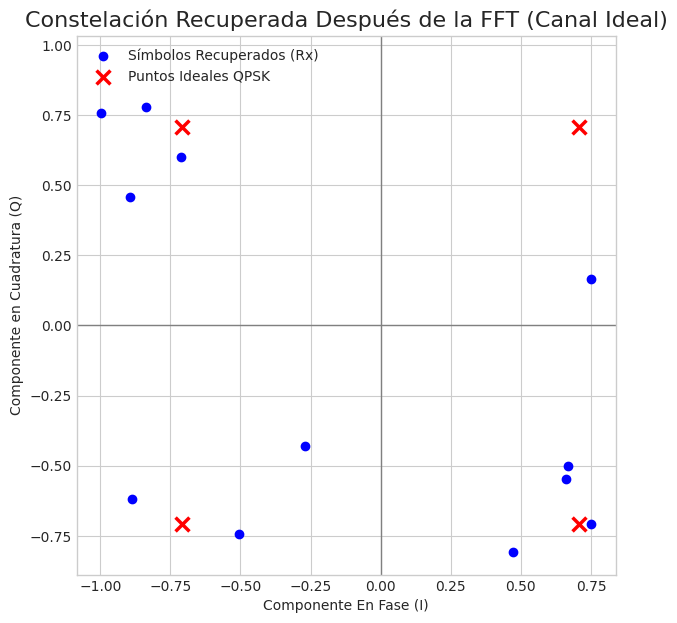

En un canal ideal, los puntos azules deben caer exactamente sobre las cruces rojas.


In [19]:
# --- Bloque 10: Demodulación FFT ---

print("Paso 10: Aplicando la FFT para volver al dominio de la frecuencia.")

# Aplicamos la FFT a cada fila (axis=1) de la matriz de tiempo.
# Es crucial usar la misma normalización 'ortho' que en la IFFT
# para que la operación sea perfectamente reversible.
Y_matrix = receptor.demodulate_with_fft(rx_matrix_no_cp)

# --- Verificación ---
print(f"Dimensiones de la matriz recuperada en frecuencia (Y_matrix): {Y_matrix.shape}")

# --- Visualización de la Constelación Recuperada ---

# Para graficar la constelación, primero debemos extraer solo los símbolos de datos.
# Usamos nuestra función de demapeo para obtener los símbolos de la primera fila de Y_matrix
first_Ym_vector = Y_matrix[0, :]
recovered_symbols_for_plot = dmp.extract_symbols_from_fft_output(first_Ym_vector)

plt.figure(figsize=(7, 7))

# Graficamos los símbolos recuperados del primer símbolo OFDM
plt.scatter(np.real(recovered_symbols_for_plot), np.imag(recovered_symbols_for_plot), 
            label='Símbolos Recuperados (Rx)', color='blue')

# Superponemos la constelación ideal para comparar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Constelación Recuperada Después de la FFT (Canal Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)')
plt.ylabel('Componente en Cuadratura (Q)')
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square')
plt.show()

print("En un canal ideal, los puntos azules deben caer exactamente sobre las cruces rojas.")

### Demapeo de Símbolos a Bits: Detección por Mínima Distancia

Una vez que hemos recuperado los símbolos complejos ($\hat{a}_k$), el paso final es revertir el proceso de mapeo para obtener la secuencia de bits original. Este proceso se conoce como **demapeo** o **detección de símbolos**.

El objetivo es, para cada símbolo complejo recibido (que en un canal real estaría afectado por ruido), decidir cuál de los cuatro símbolos de la constelación QPSK original es el que más probablemente se transmitió.

#### **El Criterio de Mínima Distancia Euclidiana**

Para un canal con ruido Gaussiano (AWGN), el criterio de decisión óptimo es el de **máxima verosimilitud (Maximum Likelihood)**, que para constelaciones con símbolos equiprobables se simplifica a encontrar el punto de la constelación ideal que tenga la **mínima distancia euclidiana** con el símbolo recibido.

En el caso de QPSK, la geometría de la constelación hace que este proceso sea extremadamente simple. Los cuatro puntos ideales de la constelación están en los cuatro cuadrantes del plano complejo. Por lo tanto, el punto más cercano a un símbolo recibido se puede determinar simplemente observando en qué cuadrante ha caído.

#### **Implementación de la Regla de Decisión**

El cuadrante de un número complejo $s = I + jQ$ está determinado por los signos de su parte real ($I$) y su parte imaginaria ($Q$).

Recordemos nuestra tabla de mapeo QPSK (con Gray mapping):

| Bits (b₁, b₂) | Cuadrante | Signo (Real, Imag) |
| :-----------: | :-------: | :----------------: |
|      00       |     1º    |      (+, +)      |
|      01       |     2º    |      (-, +)      |
|      11       |     3º    |      (-, -)      |
|      10       |     4º    |      (+, -)      |

De esta tabla, podemos derivar las reglas de decisión inversas:

1.  **Para el primer bit ($b_1$):**
    -   Observamos la parte **imaginaria** del símbolo.
    -   Si $\text{Im}(\hat{a}_k) > 0$ (cuadrantes 1 y 2), el bit $b_1$ era **0**.
    -   Si $\text{Im}(\hat{a}_k) < 0$ (cuadrantes 3 y 4), el bit $b_1$ era **1**.
    -   Esto se implementa en código como `(np.imag(ak_symbols) < 0).astype(int)`.

2.  **Para el segundo bit ($b_2$):**
    -   Observamos la parte **real** del símbolo.
    -   Si $\text{Re}(\hat{a}_k) > 0$ (cuadrantes 1 y 4), el bit $b_2$ era **0**.
    -   Si $\text{Re}(\hat{a}_k) < 0$ (cuadrantes 2 y 3), el bit $b_2$ era **1**.
    -   Esto se implementa en código como `(np.real(ak_symbols) < 0).astype(int)`.

El código en la función `demap_symbols_to_bits` aplica estas dos reglas de forma vectorizada a todo el array de símbolos recibidos, convirtiéndolos eficientemente de nuevo a una secuencia de bits.

In [20]:
# --- Bloque 11: Extracción y Demapeo de Símbolos ---

# 11.1. Extracción de los símbolos de datos de la matriz de frecuencia
print("Paso 11.1: Extrayendo los K símbolos de datos de cada vector Y_m.")

bits_rx_flat = receptor.extract_and_demap_symbols(Y_matrix, p.N_sym)

# --- Verificación ---
assert len(bits_rx_flat) == n_total_bits
print(f"Se han recuperado {len(bits_rx_flat)} bits.")

Paso 11.1: Extrayendo los K símbolos de datos de cada vector Y_m.
Se han recuperado 24000 bits.


## Ruido Blanco

**(informacion obtenida de gaussians.pdf y de Communication Systems de Haykin, despues lo adaptamos a Referencias)**

En el análisis de sistemas de comunicación, es común modelar el ruido mediante un proceso idealizado conocido como **ruido blanco**. Este se caracteriza por poseer una **densidad espectral de potencia (PSD)** constante en todas las frecuencias, lo cual implica que aporta igual potencia en todas las componentes espectrales. En sentido figurado, se lo denomina *blanco* porque, al igual que la luz blanca contiene todas las frecuencias visibles, este tipo de ruido contiene todas las frecuencias en igual proporción.

La densidad espectral de potencia del ruido blanco se expresa como:

$$
S_w(f) = \frac{N_0}{2}
$$

donde $N_0$ representa la **densidad espectral de potencia de ruido unilateral**, medida en [W/Hz]. Este parámetro suele referirse a la entrada del receptor de un sistema de comunicaciones y puede relacionarse con la temperatura equivalente de ruido mediante la expresión (representado en figura (a)):

$$
N_0 = k T_e
$$

donde $k$ es la constante de Boltzmann (cada grado Kelvin de temperatura corresponde a una cierta cantidad muy pequeña de energía por partícula) y $T_e$ la **temperatura equivalente de ruido** del receptor. Dicha temperatura se define como el valor al cual debe mantenerse un resistor ruidoso de forma que, al conectarlo a la entrada de un sistema sin ruido, se produzca la misma potencia de ruido disponible que en el sistema real. Esta definición vincula directamente las propiedades físicas del ruido térmico con el modelo matemático de ruido blanco.

Un aspecto central es que, como la función de autocorrelación es el transformado inverso de la densidad espectral de potencia, para el ruido blanco se cumple (representado en figura(b)):

$$
R_w(\tau) = \frac{N_0}{2}\,\delta(\tau)
$$

<div align="center">
  <img src="../img/whitenoise.png" width="800px"/>
</div>

Esto significa que el ruido blanco está correlacionado únicamente en $\tau = 0$. En otras palabras, dos muestras distintas de ruido blanco son no correlacionadas, y si además el proceso es gaussiano, también resultan **estadísticamente independientes**. En este sentido, el *ruido gaussiano blanco* representa el límite de la aleatoriedad en sistemas físicos.

Es importante destacar que el ruido blanco ideal posee **potencia infinita**, por lo que no es realizable físicamente. Sin embargo, como modelo matemático resulta sumamente útil en el análisis estadístico y en la teoría de sistemas, de la misma manera en que la función impulso de Dirac es empleada para describir respuestas de sistemas lineales. En la práctica, se puede modelar un proceso de ruido como blanco siempre que el ancho de banda efectivo del ruido sea considerablemente mayor que el ancho de banda del sistema bajo estudio. Bajo esta hipótesis, las simplificaciones matemáticas que brinda el modelo son válidas y permiten describir de manera precisa el comportamiento del sistema frente al ruido.


### Proceso Gaussiano y el Modelo de Ruido AWGN

#### 1. El Proceso Gaussiano

Un proceso aleatorio $X(t)$ es denominado **proceso Gaussiano** si toda funcional lineal de $X(t)$ resulta en una variable aleatoria con distribución Gaussiana. Formalmente, como se presenta en la Ecuación (1.79) de Haykin, si consideramos una variable aleatoria $Y$ definida por la integral:

$$
Y = \int_0^T g(t)X(t) dt
$$

donde $g(t)$ es una función de ponderación determinista, el proceso $X(t)$ es Gaussiano si, para toda elección de $g(t)$ que resulte en una varianza finita para $Y$, la variable aleatoria $Y$ posee una distribución Gaussiana.

Es fundamental distinguir esta definición, que involucra una **funcional** (una cantidad que depende del curso completo de una función), de una simple función lineal de variables aleatorias. El valor de $Y$ depende de la trayectoria íntegra de $X(t)$ en el intervalo $[0, T]$, no de un conjunto discreto de sus valores.

La adopción del modelo de proceso Gaussiano en el análisis de sistemas de comunicación se justifica por dos virtudes principales, como se ilustra en la Figura 1.13 del texto de referencia:

1.  **Tractabilidad Analítica:** El proceso Gaussiano posee propiedades matemáticas que permiten la obtención de resultados analíticos cerrados, simplificando considerablemente el análisis de rendimiento de los sistemas.
2.  **Justificación Física:** Numerosos fenómenos físicos, en particular el **ruido térmico** generado por el movimiento aleatorio de electrones en componentes electrónicos, producen procesos aleatorios que se aproximan fielmente a un modelo Gaussiano. Este hecho, fundamentado en el Teorema del Límite Central, está ampliamente validado por la experimentación, otorgando al modelo una sólida base física.

<div align="center">
  <img src="../img/gaussiandist.png" alt="Distribución Gaussiana Normalizada."/>
    <br>
  <em>Distribución de probabilidad Gaussiana normalizada, tal como se presenta en la Figura 1.13 de Haykin.</em>
</div>

#### 2. La Distribución Gaussiana Multivariante

En la práctica de las comunicaciones digitales, no se trabaja con el proceso continuo $X(t)$, sino con una secuencia de muestras tomadas en instantes de tiempo discretos. Una propiedad fundamental de un proceso Gaussiano, denominada **Propiedad 2** en el texto de Haykin, establece que un conjunto de muestras tomadas en distintos instantes de tiempo, $X(t_1), X(t_2), \dots, X(t_n)$, es **conjuntamente Gaussiano**.

Esto implica que el vector aleatorio $\mathbf{X}$ de $n$ dimensiones, formado por estas muestras, sigue una **distribución Gaussiana multivariante**. La función de densidad de probabilidad (PDF) conjunta de este vector queda completamente determinada por su vector de medias y su matriz de covarianza, como se expresa en la Ecuación (1.85) de Haykin:

$$
f_{\mathbf{X}}(x_1, \dots, x_n) = \frac{1}{(2\pi)^{n/2} \Delta^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \mathbf{\mu})\right)
$$

Los componentes de esta ecuación se definen como:
*   **$\mathbf{x}$**: Es un vector de $n$ dimensiones que representa una realización específica del proceso de ruido muestreado. En el contexto de la simulación, corresponde al vector `noise` generado.
*   **$\mathbf{\mu}$ (Vector de Medias)**: Es un vector de $n$ dimensiones cuyo $i$-ésimo elemento es la media de la muestra en el instante $t_i$, i.e., $\mu_i = E[X(t_i)]$. Para el ruido térmico, que carece de componente de corriente continua (DC), este vector es nulo ($\mathbf{\mu} = \mathbf{0}$).
*   **$\mathbf{\Sigma}$ (Matriz de Covarianza)**: Es una matriz de $n \times n$ que caracteriza la estructura de correlación temporal del proceso. El elemento $(k, l)$ de la matriz es la covarianza entre las muestras en los instantes $t_k$ y $t_l$:
    $$ \Sigma_{kl} = C_X(t_k, t_l) = E[(X(t_k) - \mu_k)(X(t_l) - \mu_l)] $$
    Esta matriz encapsula tanto la potencia de las muestras de ruido (en su diagonal) como la dependencia estadística entre ellas (en los elementos fuera de la diagonal).
*   $\mathbf{\Sigma}^{-1}$ y $\Delta$ son, respectivamente, la inversa y el determinante de la matriz de covarianza.

#### 3. El Modelo de Ruido Aditivo Blanco Gaussiano (AWGN)

El modelo AWGN es la síntesis de los conceptos de ruido blanco y proceso Gaussiano, y representa el escenario de ruido más fundamental en el análisis de sistemas de comunicación.

1.  **Aditivo (A):** El ruido se superpone linealmente (se suma) a la señal de interés.
2.  **Blanco (W):** Como se estableció en la sección anterior, la propiedad "blanca" implica que la función de autocorrelación del ruido es un impulso de Dirac, $R_w(\tau) = (N_0/2)\delta(\tau)$. Esto tiene una consecuencia directa sobre la matriz de covarianza $\mathbf{\Sigma}$ de las muestras: la covarianza entre dos instantes distintos es cero.
    $$ C_X(t_k, t_l) = 0 \quad \text{para } k \neq l $$
    Por lo tanto, para un proceso de ruido blanco, la matriz de covarianza **es diagonal**. Además, si el proceso es estacionario, la potencia en cada instante es la misma, $\text{Var}(X(t_i)) = \sigma^2$. Esto simplifica la matriz de covarianza a:
    $$ \mathbf{\Sigma} = \sigma^2 \mathbf{I} $$
    donde $\mathbf{I}$ es la matriz identidad.

3.  **Gaussiano (G):** El vector de muestras de ruido sigue la distribución Gaussiana multivariante descrita anteriormente.

### La Matriz de Covarianza en Procesos Gaussianos

En el caso de un vector aleatorio $\mathbf{X} = [X_1, X_2, \dots, X_n]^T$, la **matriz de covarianza** $\mathbf{\Sigma}$ se define como:

$$
\Sigma = E\left[(\mathbf{X} - \mathbf{\mu})(\mathbf{X} - \mathbf{\mu})^T\right]
= \begin{bmatrix}
\text{Var}(X_1) & \text{Cov}(X_1,X_2) & \dots & \text{Cov}(X_1,X_n) \\
\text{Cov}(X_2,X_1) & \text{Var}(X_2) & \dots & \text{Cov}(X_2,X_n) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(X_n,X_1) & \text{Cov}(X_n,X_2) & \dots & \text{Var}(X_n)
\end{bmatrix}
$$

- Los elementos diagonales representan las **varianzas** de cada componente.  
- Los elementos fuera de la diagonal representan las **covarianzas**, es decir, el grado de correlación lineal entre dos variables.  

### Caso Diagonal: Independencia de Muestras

Si las muestras de ruido son **independientes**, la covarianza entre ellas es nula:

$$
\text{Cov}[X_i, X_j] = 0 \quad \text{para } i \neq j
$$

Esto implica que la matriz de covarianza se reduce a una forma **diagonal**:

$$
\mathbf{\Sigma} =
\begin{bmatrix}
\sigma^2 & 0 & 0 & \dots & 0 \\
0 & \sigma^2 & 0 & \dots & 0 \\
0 & 0 & \sigma^2 & \dots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \dots & \sigma^2
\end{bmatrix}
= \sigma^2 \mathbf{I}
$$

donde $\mathbf{I}$ es la matriz identidad.

En un sistema **OFDM**, cada **subportadora** se ve afectada por el ruido de manera independiente (bajo el modelo AWGN).  
- Si modelamos el vector de muestras de ruido en $n$ subportadoras como $\mathbf{W} = [W_1, W_2, \dots, W_n]^T$,  
- Entonces $\mathbf{W} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$.  

Esto significa que:
- Cada subportadora recibe un ruido gaussiano independiente con la misma potencia.  
- No existe correlación entre el ruido de diferentes subportadoras (los términos fuera de la diagonal son cero).  

Por lo tanto, el modelo de **matriz de covarianza diagonal** describe perfectamente el escenario de OFDM bajo ruido blanco.


## Relación Señal-Ruido (SNR)

Una vez establecido el modelo estadístico del ruido, es imperativo definir métricas que cuantifiquen su impacto sobre la señal transmitida. La potencia absoluta del ruido no es, por sí misma, un indicador suficiente del desempeño; el factor determinante es la magnitud relativa entre la señal y el ruido.

## 1. Definición Fundamental de SNR

La **Relación Señal-Ruido (SNR)** es la métrica fundamental que compara la potencia promedio de la señal, $P_{\text{señal}}$, con la potencia promedio del ruido, $P_{\text{ruido}}$, en un ancho de banda de interés.

$$
\text{SNR} = \frac{P_{\text{señal}}}{P_{\text{ruido}}}
$$

Esta relación puede expresarse en escala **lineal** (adimensional) o, más comúnmente, en **decibelios (dB)**:

$$
\text{SNR}_{\text{dB}} = 10 \log_{10}\left(\text{SNR}\right)
$$

En un sistema afectado por **ruido blanco aditivo Gaussiano (AWGN)**, el ruido se caracteriza por una densidad espectral de potencia (PSD) $N_0$ (unilateral, en W/Hz). La potencia total de este ruido, integrada sobre el ancho de banda del sistema $B$, es:

$$
P_{\text{ruido}} = N_0 \cdot B
$$

Sustituyendo esta expresión, obtenemos la definición de SNR en función de los parámetros del canal:

$$
\boxed{\text{SNR} = \frac{P_{\text{señal}}}{N_0 \cdot B}}
$$

> **Intuición:** Para una potencia de señal fija, un **mayor ancho de banda ($B$)** implica la integración de una mayor cantidad de ruido, lo que resulta en una **menor SNR**.

---

## 2. La Conexión con la Energía por Bit y por Símbolo

Mientras que la SNR describe potencias promedio, la detección en un receptor digital se realiza a nivel de símbolos o bits individuales. Por ello, es crucial relacionar la SNR con la energía asociada a estas unidades de información.

-   **Energía por Bit ($E_b$)**: Es la energía que el transmisor dedica a enviar un único bit de información. Se relaciona con la potencia de la señal a través de la tasa de bits, $R_b$ (en bits/s):
    $$ E_b = \frac{P_{\text{señal}}}{R_b} $$
-   **Energía por Símbolo ($E_s$)**: Análogamente, es la energía dedicada a un símbolo, relacionada con la tasa de símbolos, $R_s$ (en símbolos/s):
    $$ E_s = \frac{P_{\text{señal}}}{R_s} $$

Manipulando algebraicamente estas definiciones, obtenemos la relación fundamental entre SNR y $E_b/N_0$:

$$
\boxed{\frac{E_b}{N_0} = \text{SNR} \cdot \frac{B}{R_b}}
\quad \Longleftrightarrow \quad
\boxed{\text{SNR} = \frac{E_b}{N_0} \cdot \frac{R_b}{B}}
$$

El término $R_b/B$ se conoce como **eficiencia espectral**, medida en (bits/s)/Hz. Esta ecuación revela un compromiso fundamental en el diseño de sistemas:

> **Intuición:** Para mantener una calidad de señal constante (un $E_b/N_0$ fijo), un sistema con **mayor eficiencia espectral** (más bits empaquetados en el mismo ancho de banda) requiere una **SNR más alta**.

Para una modulación $M$-aria, donde cada símbolo representa $\mu = \log_2 M$ bits, las relaciones equivalentes para la energía por símbolo son:

$$
\boxed{\frac{E_s}{N_0} = \frac{E_b}{N_0} \cdot \log_2 M}
\quad \text{y} \quad
\boxed{\frac{E_s}{N_0} = \text{SNR} \cdot \frac{B}{R_s}}
$$

---

## 3. SNR en Sistemas OFDM

El paradigma de OFDM divide un canal de banda ancha $B$ en un gran número de subcanales ortogonales y de banda estrecha. Esto nos permite analizar la SNR no solo a nivel global, sino a nivel de cada **subportadora individual**.

Supongamos un sistema OFDM con $N_{sub}$ subportadoras, cada una con un ancho de banda angosto $\Delta f$. La relación con el ancho de banda total es $B \approx N_{sub} \cdot \Delta f$. En un canal AWGN plano (cuya respuesta en frecuencia es constante), podemos analizar la SNR en la $k$-ésima subportadora:

-   **Potencia de Ruido por Subportadora**: El ruido blanco se distribuye uniformemente. La potencia de ruido integrada en el pequeño ancho de banda $\Delta f$ de la subportadora $k$ es:
    $$ P_{ruido, k} = N_0 \cdot \Delta f $$
-   **Potencia de Señal por Subportadora**: Si la potencia total de la señal, $P_{\text{señal}}$, se distribuye uniformemente entre todas las subportadoras de datos ($K$), la potencia en la subportadora $k$ es:
    $$ P_{señal, k} = \frac{P_{\text{señal}}}{K} $$

Por lo tanto, la SNR en la $k$-ésima subportadora es:

$$
\boxed{\text{SNR}_k = \frac{P_{\text{señal}, k}}{P_{ruido, k}} = \frac{P_{\text{señal}} / K}{N_0 \cdot \Delta f}}
$$

En un canal AWGN ideal, donde la respuesta del canal es plana ($|H_k|^2=1$ para todo $k$), la SNR es la misma para todas las subportadoras.

### Impacto del Prefijo Cíclico (CP) en la SNR

El Prefijo Cíclico es esencial para la robustez de OFDM contra el multitrayecto, pero introduce una sobrecarga que impacta la eficiencia energética. Si se mantiene constante la **potencia promedio total** de la señal transmitida (incluyendo el CP), una fracción de esa potencia se utiliza en transmitir el CP, que es redundante y se descarta en el receptor.

La duración total de un símbolo OFDM, $T_s$, se compone del tiempo útil, $T_u$ (correspondiente a las muestras de la IFFT), y la duración del CP, $T_{cp}$.

$$ T_s = T_u + T_{cp} $$

La fracción de tiempo (y por ende, de energía) que corresponde a la información útil es:

$$ \eta = \frac{T_u}{T_s} = \frac{T_u}{T_u + T_{cp}} $$

Esta sobrecarga resulta en una penalización en la energía útil por símbolo y, consecuentemente, en la SNR efectiva. La energía útil del símbolo se reduce por este factor $\eta$.

$$
E_{s, \text{efectiva}} = \eta \cdot E_s
$$

Esto se traduce directamente en una reducción de la SNR por subportadora:

$$
\text{SNR}_{k, \text{efectiva}} \approx \eta \cdot \text{SNR}_k
$$

La **penalidad en la SNR** debida al prefijo cíclico, expresada en decibelios, es:

$$
\text{Penalidad}_{\text{dB}} = 10 \log_{10}(\eta)
$$

> **Ejemplo Numérico:** En el estándar LTE, una configuración común usa un tiempo útil $T_u = 66.67 \, \mu s$ y un prefijo cíclico normal $T_{cp} = 4.69 \, \mu s$.
> $$ \eta = \frac{66.67}{66.67 + 4.69} \approx 0.934 $$
> $$ \text{Penalidad}_{\text{dB}} = 10 \log_{10}(0.934) \approx \mathbf{-0.296 \text{ dB}} $$
> Esto significa que casi 0.3 dB de la potencia transmitida se pierde debido a la sobrecarga del CP.

# Análisis del Rendimiento

El propósito fundamental de un sistema de comunicación digital es la transmisión fiable de información a través de un canal no ideal. La métrica cuantitativa por excelencia para evaluar esta fiabilidad es la **Probabilidad de Error de Bit (BER)**, también denotada como $P_b$.

### 1. Definición y Fundamento

La tasa de error de bits (BER) se define como la probabilidad de que un bit de información sea detectado incorrectamente en el receptor. En un entorno de simulación o medición, se estima como la tasa de error de bit:

$$
\text{BER} = \frac{\text{Número de bits recibidos erróneamente}}{\text{Número total de bits transmitidos}}
$$

En un análisis teórico, el objetivo es derivar una expresión matemática para $P_b$ en función de los parámetros del sistema y del canal. Para el canal **Aditivo Blanco Gaussiano (AWGN)**, el único mecanismo de error es la perturbación de la señal por el ruido térmico.

### 2. Detección Óptima en Canales AWGN

Consideremos un esquema de modulación digital donde los bits se mapean a un conjunto de símbolos $s_i$. La señal transmitida, $s(t)$, se ve corrompida por un proceso de ruido aditivo $n(t)$, resultando en una señal recibida $r(t) = s(t) + n(t)$.

El receptor óptimo para un canal AWGN implementa una regla de decisión basada en el principio de **máxima verosimilitud (Maximum Likelihood)**. Para símbolos equiprobables, este criterio se simplifica a la regla de **mínima distancia Euclidiana**. El espacio de señales se divide en **regiones de decisión**, y el receptor decide que el símbolo transmitido fue $\hat{s}_i$ si la señal recibida se encuentra más cerca de $s_i$ que de cualquier otro símbolo de la constelación.

Un error de decisión ocurre cuando la magnitud del vector de ruido es tal que desplaza la señal recibida fuera de su región de decisión correcta y la ubica dentro de la región de un símbolo distinto. La probabilidad de este evento determina el rendimiento del sistema.

### 3. Función Q (Bixio)

En el análisis de sistemas de comunicación sobre canales AWGN, el cálculo de la probabilidad de error se reduce fundamentalmente a cuantificar la probabilidad de que una variable aleatoria Gaussiana (representando la señal más el ruido) cruce un umbral de decisión. Esta probabilidad se expresa de manera estándar y compacta mediante la **función Q**

#### 3.1 Definición Matemática

La función Q, $Q(x)$, se define como la integral de la cola derecha de la función de densidad de probabilidad (PDF) de una distribución Gaussiana normalizada, es decir, una distribución con media cero y varianza unitaria, $\mathcal{N}(0, 1)$.

Matemáticamente, su definición es:
$$
Q(x) := \frac{1}{\sqrt{2\pi}} \int_x^{\infty} e^{-\xi^2/2} d\xi
$$

Por definición, $Q(x)$ representa la probabilidad de que una variable aleatoria $Z \sim \mathcal{N}(0, 1)$ tome un valor mayor o igual a $x$:
$$
Q(x) = P(Z \geq x)
$$

Esta función no tiene una solución analítica en forma cerrada, por lo que se evalúa numéricamente o se aproxima mediante cotas y expansiones.

#### 3.2 Relación con la Función de Error (erf/erfc)

La función Q está directamente relacionada con la **función de error complementaria (erfc)**, que es comúnmente encontrada en software de análisis numérico y estadística. La relación es la siguiente:
$$
Q(x) = \frac{1}{2} \text{erfc}\left(\frac{x}{\sqrt{2}}\right)
$$
donde la función de error complementaria se define como:
$$
\text{erfc}(z) = \frac{2}{\sqrt{\pi}} \int_z^{\infty} e^{-t^2} dt
$$
Esta equivalencia es fundamental para la implementación práctica del cálculo de la BER en simulaciones.

#### 3.3 Propiedades Fundamentales

La función Q posee varias propiedades importantes que se derivan directamente de su naturaleza como integral de una PDF:

1.  **Límites y Valores Notables:**
    *   $Q(-\infty) = 1$
    *   $Q(0) = \frac{1}{2}$ (La probabilidad de que una variable Gaussiana de media cero sea positiva es 0.5, lo que corresponde a un BER de 50% en ausencia de señal, equivalente al azar).
    *   $Q(\infty) = 0$

2.  **Simetría:** Debido a la simetría de la PDF Gaussiana alrededor de su media, la función Q exhibe la siguiente propiedad:
    $$
    Q(-x) = 1 - Q(x)
    $$
    Esto implica que la función de distribución acumulada (CDF) de una variable $Z \sim \mathcal{N}(0, 1)$, denotada como $\Phi(x) = P(Z \leq x)$, se relaciona con la función Q como $\Phi(x) = 1 - Q(x)$.

3.  **Generalización para una Distribución Gaussiana Arbitraria:**
    Si una variable aleatoria $Y$ sigue una distribución Gaussiana con media $m$ y varianza $\sigma^2$, es decir, $Y \sim \mathcal{N}(m, \sigma^2)$, la probabilidad $P(Y \geq y)$ puede expresarse en términos de la función Q mediante una normalización:
    $$
    P(Y \geq y) = P\left(\frac{Y-m}{\sigma} \geq \frac{y-m}{\sigma}\right) = Q\left(\frac{y-m}{\sigma}\right)
    $$
    Este resultado es central, ya que permite aplicar la función Q estándar al análisis de cualquier proceso Gaussiano, simplemente normalizando la variable por su media y desviación estándar. Es precisamente esta propiedad la que se utiliza para derivar las fórmulas de BER, donde el argumento de la función Q contiene términos relacionados con la energía de la señal y la potencia del ruido.

#### 3.4 Cotas y Aproximaciones

Dado que no existe una forma cerrada para $Q(x)$, se utilizan cotas y aproximaciones para su análisis y cálculo. Una de las cotas superiores más conocidas y útiles para valores grandes de $x$ es la **cota de Chernoff**:
$$
Q(x) \leq \frac{1}{2} e^{-x^2/2}, \quad \text{para } x \geq 0
$$
Una cota más ajustada para $x > 0$ es:
$$
\frac{1}{\sqrt{2\pi}x}\left(1-\frac{1}{x^2}\right)e^{-x^2/2} < Q(x) < \frac{1}{\sqrt{2\pi}x}e^{-x^2/2}
$$
Estas cotas demuestran que la función Q decae de forma exponencialmente rápida a medida que su argumento aumenta. Esta característica explica la forma de "cascada" de las curvas de BER: pequeños incrementos en la SNR (que aumentan el argumento de la función Q) producen reducciones drásticas en la probabilidad de error.

### 4. Probabilidad de Error

La probabilidad de error de bit para los esquemas de modulación más comunes en canales AWGN se puede expresar directamente en términos de la función Q y la relación $E_b/N_0$.

#### Modulación por Desplazamiento de Fase Binaria (BPSK) y en Cuadratura (QPSK)

Tanto para BPSK como para QPSK (utilizando codificación Gray), la probabilidad de error de bit es idéntica y viene dada por la expresión exacta:
$$
P_b = Q\left(\sqrt{\frac{2E_b}{N_0}}\right)
$$
La equivalencia en el rendimiento de BER se debe a la ortogonalidad de las componentes en fase y en cuadratura de la QPSK, lo que permite que la detección de los bits en cada componente sea estadísticamente independiente y análoga a dos canales BPSK paralelos.

#### Modulación de Amplitud en Cuadratura (M-QAM)

Para constelaciones de orden superior como M-QAM, las expresiones son más complejas, ya que existen múltiples distancias entre símbolos y diferentes tipos de errores de símbolo. Para una constelación M-QAM cuadrada ($M=2^k$ con $k$ par), una aproximación muy precisa para la BER es:
$$
P_b \approx \frac{4}{\log_2 M}\left(1 - \frac{1}{\sqrt{M}}\right) Q\left(\sqrt{\frac{3 \log_2 M}{M-1} \frac{E_b}{N_0}}\right)
$$

Cada esquema de modulación posee una curva de rendimiento característica que relaciona la BER con $E_b/N_0$.

### 5. Interpretación de la Curva de Rendimiento BER vs. $E_b/N_0$

La representación gráfica de la BER en función de $E_b/N_0$ es la herramienta estándar para visualizar y comparar el rendimiento de los sistemas de comunicación.

-   **Eje X (Abscisa):** La relación $E_b/N_0$, expresada en decibelios (dB). El uso de esta métrica normalizada permite una comparación universal entre sistemas.
-   **Eje Y (Ordenada):** La Probabilidad de Error de Bit ($P_b$), representada en **escala logarítmica**. Esta escala es esencial para visualizar órdenes de magnitud de error muy pequeños (e.g., $10^{-3}$ a $10^{-9}$), que son los rangos de operación típicos en sistemas reales.

La forma de la curva es característicamente una **"cascada" (waterfall)** que decrece monotónicamente: a medida que aumenta la relación $E_b/N_0$, la BER disminuye exponencialmente. Esta curva permite:
1.  **Determinar Requisitos de Potencia:** Para un BER objetivo (ej., $10^{-6}$ para enlaces de datos fiables), la curva indica el $E_b/N_0$ mínimo requerido, lo cual se traduce en un requisito de potencia para el transmisor.
2.  **Comparar Modulaciones:** Al superponer las curvas de diferentes esquemas de modulación, se pueden cuantificar los compromisos. Por ejemplo, se puede observar cuántos dB adicionales de $E_b/N_0$ requiere 16-QAM en comparación con QPSK para alcanzar la misma BER, a cambio de duplicar la eficiencia espectral.
3.  **Validar Simulaciones:** La curva teórica sirve como referencia para validar la correcta implementación de un modelo de simulación.

--- Iniciando Simulación de Monte Carlo para Curva BER ---

Simulando para Eb/N0 = 0 dB...
  -> Bits simulados: 24000, Errores contados: 1875
  -> BER final: 7.812e-02 (calculado en 0.03s)

Simulando para Eb/N0 = 1 dB...
  -> Bits simulados: 24000, Errores contados: 1218
  -> BER final: 5.075e-02 (calculado en 0.02s)

Simulando para Eb/N0 = 2 dB...
  -> Bits simulados: 24000, Errores contados: 815
  -> BER final: 3.396e-02 (calculado en 0.04s)

Simulando para Eb/N0 = 3 dB...
  -> Bits simulados: 24000, Errores contados: 470
  -> BER final: 1.958e-02 (calculado en 0.03s)

Simulando para Eb/N0 = 4 dB...
  -> Bits simulados: 48000, Errores contados: 507
  -> BER final: 1.056e-02 (calculado en 0.06s)

Simulando para Eb/N0 = 5 dB...
  -> Bits simulados: 96000, Errores contados: 499
  -> BER final: 5.198e-03 (calculado en 0.11s)

Simulando para Eb/N0 = 6 dB...
  -> Bits simulados: 216000, Errores contados: 414
  -> BER final: 1.917e-03 (calculado en 0.26s)

Simulando para Eb/N0 = 7 dB...
  -

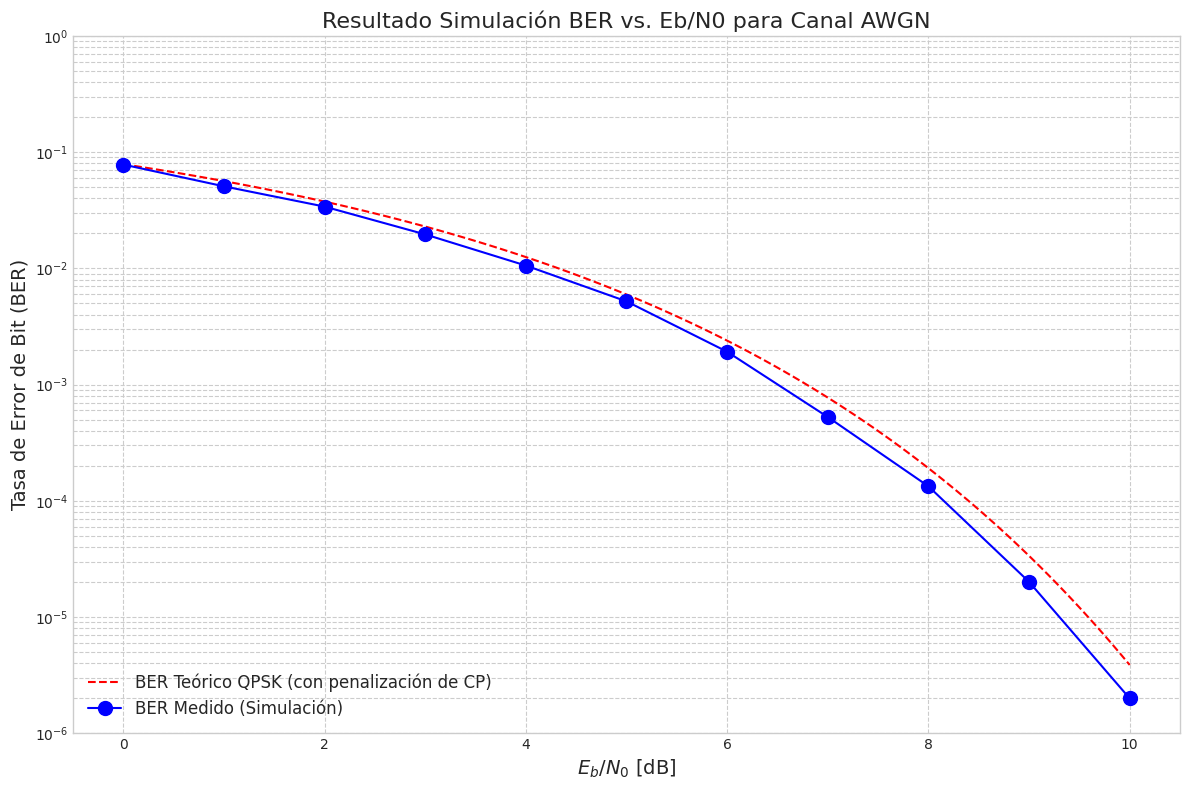

In [21]:
# --- Bloque 12: Ejecución de Simulación y Gráfica de Resultados ---

# Este bloque actúa como un panel de control.
# Decide qué simulación ejecutar y cómo graficarla basándose en MODO_CANAL.

if MODO_CANAL == "awgn":
    # --- MODO AWGN: Ejecutar simulación de Monte Carlo ---
    
    # 1. Definir los parámetros para la simulación
    ebn0_db_range = np.arange(0, 11, 1)  # Simular de 0 a 10 dB

    # 2. Ejecutar la simulación de Monte Carlo
    ber_medidos = utils.run_montecarlo_simulation(
        ebn0_db_range,
        min_errors=400,
        max_bits=8000000
    )

    # 3. Preparar la gráfica de la curva BER
    plt.figure(figsize=(12, 8))
    
    # Curva Teórica de Referencia
    ebn0_axis_teorico = np.linspace(0, 10, 100)
    ebn0_lin_range = 10**(ebn0_axis_teorico / 10)
    #eta = p.N / (p.N + p.L)
    ebn0_efectivo_lin = ebn0_lin_range # * eta
    ber_teo_curve = 0.5 * erfc(np.sqrt(ebn0_efectivo_lin))
    plt.semilogy(ebn0_axis_teorico, ber_teo_curve, 'r--', label='BER Teórico QPSK (con penalización de CP)')

    # Resultados de la Simulación de Monte Carlo
    ber_graficable = [ber if ber > 0 else 1e-9 for ber in ber_medidos]
    plt.semilogy(ebn0_db_range, ber_graficable, 'bo-', markersize=10, label='BER Medido (Simulación)')

    # Estética del gráfico
    plt.ylim([1e-6, 1])
    plt.title('Resultado Simulación BER vs. Eb/N0 para Canal AWGN', fontsize=16)
    plt.xlabel("$E_b/N_0$ [dB]", fontsize=14)
    plt.ylabel("Tasa de Error de Bit (BER)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()

elif MODO_CANAL == "ideal":
    # --- MODO IDEAL: Ejecutar una sola pasada de verificación ---
    
    # 1. Calcular el BER real (debería ser 0)
    bit_errors = int(np.sum(bits_tx != bits_rx_flat))
    n_bits = len(bits_rx_flat)
    ber_real = bit_errors / n_bits if n_bits > 0 else 0.0

    print(f"--- Resultados para Canal Ideal ---")
    print(f"Errores de bit: {bit_errors} / {n_bits} -> BER medido = {ber_real:.2e}")
    assert ber_real == 0, "Se encontraron errores en el canal ideal."

    # 2. Graficar el resultado
    plt.figure(figsize=(12, 8))
    ebn0_axis = np.linspace(-2, 16, 100)
    ber_floor_plot = 1e-7 # Un "piso" para visualización en escala logarítmica
    
    plt.semilogy(ebn0_axis, np.full_like(ebn0_axis, ber_floor_plot), 'g-', linewidth=3,
                 label=f"BER Medido ({bit_errors} errores)")
    
    plt.annotate('BER real = 0\n(se dibuja en un piso visual)',
                 xy=(8, ber_floor_plot), xytext=(8, ber_floor_plot * 100),
                 arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=5),
                 fontsize=11, ha='center',
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9))

    # Estética del gráfico
    plt.ylim([1e-10, 1])
    plt.title("Verificación de BER en Canal Ideal (sin ruido)", fontsize=16)
    plt.xlabel("$E_b/N_0$ [dB] (Eje de referencia)", fontsize=14)
    plt.ylabel("BER (escala logarítmica)", fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Modo de canal '{MODO_CANAL}' no reconocido.")